In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

versions known to work - 
matplotlib: 3.4.2
numpy: 1.20.3
scipy: 1.4.1
pandas: 1.5.3
seaborn: 0.12.2
allensdk: 2.16.2

In [3]:
import matplotlib
print('matplotlib:', matplotlib.__version__)
import numpy
print('numpy:', numpy.__version__)
import scipy
print('scipy:', scipy.__version__)
import pandas 
print('pandas:', pandas.__version__)
import seaborn
print('seaborn:', seaborn.__version__)
import allensdk
print('allensdk:', allensdk.__version__)

matplotlib: 3.4.2
numpy: 1.22.0
scipy: 1.4.1
pandas: 1.5.3
seaborn: 0.13.0
allensdk: 2.16.2


In [4]:
import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading

import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

In [5]:
experience_levels = utils.get_new_experience_levels()
experience_level_colors = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

### load experiments and cells tables

In [6]:
loading.get_platform_analysis_cache_dir()

'\\\\allen\\programs\\braintv\\workgroups\\nc-ophys\\visual_behavior\\platform_paper_cache_new'

In [ ]:
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = VisualBehaviorOphysProjectCache.from_local_cache(cache_dir=platform_cache_dir, use_static_cache=True)

ophys_experiment_table = cache.get_ophys_experiment_table()
ophys_experiment_table = utilities.add_extra_columns_to_experiment_table(ophys_experiment_table)
ophys_cells_table = cache.get_ophys_cells_table()
ophys_cells_table = ophys_cells_table.merge(ophys_experiment_table, on='ophys_experiment_id')
print(len(ophys_experiment_table))

c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


1936


#### Regenerate platform tables if needed

In [8]:
# platform_experiments = loading.get_platform_paper_experiment_table(limit_to_closest_active=True)

# # oeids = [920288845, 920288849]
# # platform_experiments = platform_experiments.drop(index=oeids)

# print('CHECKING PLATFORM EXPERIMENTS TABLE')
# print(len(platform_experiments.mouse_id.unique()), 'mice')
# print(len(platform_experiments.ophys_session_id.unique()), 'sessions')
# print(len(platform_experiments.ophys_container_id.unique()), 'containers')
# print(len(platform_experiments.index.unique()), 'experiments')
# print(platform_experiments.experience_level.unique())

In [9]:
# platform_cells_table = ophys_cells_table[ophys_cells_table.ophys_experiment_id.isin(platform_experiments.index.values)]
# platform_cells_table['experience_level'] = [utils.convert_experience_level(experience_level) for experience_level in platform_cells_table.experience_level.values]
# csids = [1086560073, 1086562892, 1086577313, 1086560671]
# platform_cells_table = platform_cells_table[platform_cells_table.cell_specimen_id.isin(csids)==False]
# platform_cells_table.drop_duplicates(subset=['cell_specimen_id']).groupby(['cre_line']).count()

# print('CHECKING PLATFORM CELLS TABLE')
# print(platform_cells_table.experience_level.unique())
# print(len(platform_cells_table.mouse_id.unique()), 'mice')
# print(len(platform_cells_table.ophys_session_id.unique()), 'sessions')
# print(len(platform_cells_table.ophys_container_id.unique()), 'containers')
# print(len(platform_cells_table.ophys_experiment_id.unique()), 'experiments')
# print(len(platform_cells_table.cell_specimen_id.unique()), 'cells')
# print(platform_cells_table.drop_duplicates(subset=['cell_specimen_id']).groupby(['cre_line']).count()[['cell_specimen_id']])


In [10]:
# matched_cells_table = utilities.limit_to_cell_specimen_ids_matched_in_all_experience_levels(platform_cells_table)

# print('CHECKING MATCHED CELLS TABLE')
# print(matched_cells_table.experience_level.unique())
# print(len(matched_cells_table.mouse_id.unique()), 'mice')
# print(len(matched_cells_table.ophys_session_id.unique()), 'sessions')
# print(len(matched_cells_table.ophys_container_id.unique()), 'containers')
# print(len(matched_cells_table.ophys_experiment_id.unique()), 'experiments')
# print(len(matched_cells_table.cell_specimen_id.unique()), 'cells')
# print(matched_cells_table.drop_duplicates(subset=['cell_specimen_id']).groupby(['cre_line']).count()[['cell_specimen_id']])

In [11]:
# platform_experiments.to_csv(os.path.join(platform_cache_dir, 'platform_paper_ophys_experiments_table.csv'))
# platform_cells_table.to_csv(os.path.join(platform_cache_dir, 'platform_paper_ophys_cells_table.csv'))
# matched_cells_table.to_csv(os.path.join(platform_cache_dir, 'platform_paper_matched_ophys_cells_table.csv'))


#### Load tables

In [12]:
# metadata tables
experiments_table = pd.read_csv(os.path.join(platform_cache_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(platform_cache_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(platform_cache_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(platform_cache_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# get lists of matched cells and expts
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# get cre_lines and cell types for plot labels
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utilities.get_cell_types_dict(cre_lines, platform_experiments)


In [13]:
print(len(experiments_table.mouse_id.unique()), 'mice')
print(len(experiments_table.ophys_session_id.unique()), 'sessions')
print(len(experiments_table.ophys_container_id.unique()), 'containers')
print(len(experiments_table.index.unique()), 'experiments')

107 mice
703 sessions
326 containers
1936 experiments


In [14]:
print(len(platform_experiments.mouse_id.unique()), 'mice')
print(len(platform_experiments.ophys_session_id.unique()), 'sessions')
print(len(platform_experiments.ophys_container_id.unique()), 'containers')
print(len(platform_experiments.index.unique()), 'experiments')

66 mice
202 sessions
134 containers
402 experiments


In [15]:
print(len(platform_cells_table.mouse_id.unique()), 'mice')
print(len(platform_cells_table.ophys_experiment_id.unique()), 'expriments')
print(len(platform_cells_table.ophys_session_id.unique()), 'sessions')
print(len(platform_cells_table.ophys_container_id.unique()), 'containers')
print(len(platform_cells_table.cell_specimen_id.unique()), 'cells')

66 mice
402 expriments
202 sessions
134 containers
14491 cells


In [16]:
print(len(matched_cells_table.mouse_id.unique()), 'mice')
print(len(matched_cells_table.ophys_container_id.unique()), 'containers')
print(len(matched_cells_table.cell_specimen_id.unique()), 'matched cells')

65 mice
131 containers
3917 matched cells


### how many containers per mouse? 

In [ ]:
2 Novel+
3 Familiar

In [33]:
mice = [435431, 438912, 541329, 544965]

In [ ]:
exception_session_ids =[886130638, # 270, 1018028374
                        846871218,	#75	1018027847, 225	1018027853
                        1078792791,	#228	1074913340, 229	1074913354	
                        1075872563,]	#273	1074922997, 1076418903	276	

In [40]:
platform_experiments.columns

Index(['behavior_session_id', 'ophys_session_id', 'ophys_container_id',
       'mouse_id', 'indicator', 'full_genotype', 'driver_line', 'cre_line',
       'reporter_line', 'sex', 'age_in_days', 'imaging_depth',
       'targeted_structure', 'targeted_imaging_depth', 'imaging_plane_group',
       'project_code', 'session_type', 'session_number', 'image_set',
       'behavior_type', 'passive', 'experience_level',
       'prior_exposures_to_session_type', 'prior_exposures_to_image_set',
       'prior_exposures_to_omissions', 'date_of_acquisition', 'equipment_name',
       'published_at', 'isi_experiment_id', 'file_id', 'cell_type', 'depth',
       'binned_depth', 'area_depth', 'area_binned_depth', 'layer',
       'area_layer', 'date', 'first_novel', 'n_relative_to_first_novel',
       'last_familiar', 'last_familiar_active', 'second_novel',
       'second_novel_active', 'experience_exposure'],
      dtype='object')

In [44]:
platform_experiments[(platform_experiments.project_code=='VisualBehaviorMultiscope') & 
                     (platform_experiments.mouse_id.isin(mice))].reset_index().groupby(['mouse_id',  'experience_level', 'ophys_session_id', 'targeted_imaging_depth', 'ophys_container_id']).count()[:50]

ophys_experiment_id  \
mouse_id experience_level ophys_session_id targeted_imaging_depth ophys_container_id                        
435431   Familiar         882060185        74                     1018028364                            1   
                                           153                    1018028367                            1   
                                           220                    1018028370                            1   
                                           273                    1018028374                            1   
                                           303                    1018028387                            1   
         Novel            882674040        74                     1018028364                            1   
                                           153                    1018028367                            1   
                                           220                    1018028370                            1   
                                           273                    1018028374                            1   
                                           303                    1018028387                            1   
         Novel +          884451806        74                     1018028364                            1   
                                           153                    1018028367                            1   
                                           220                    1018028370                            1   
                                           303                    1018028387                            1   
                          886130638        273                    1018028374                            1   
438912   Familiar         846871218        75                     1018027847                            1   
                                           225                    1018027853                            1   
                          848401585        75                     1018027859                            1   
                                           150                    1018027862                            1   
                                           225                    1018027865                            1   
                                           300                    1018027868                            1   
         Novel            848983781        75                     1018027847                            1   
                                                                  1018027859                            1   
                                           150                    1018027862                            1   
                                           225                    1018027853                            1   
                                                                  1018027865                            1   
                                           300                    1018027868                            1   
         Novel +          850894918        75                     1018027847                            1   
                                                                  1018027859                            1   
                                           150                    1018027862                            1   
                                           225                    1018027853                            1   
                                                                  1018027865                            1   
                                           300                    1018027868                            1   
541329   Familiar         1075872563       273                    1074922997                            1   
                          1076418903       276                    1074922983                            1   
         Novel            1076653403       273       

In [23]:
platform_experiments[platform_experiments.project_code=='VisualBehaviorMultiscope'].groupby(['mouse_id',  'experience_level', 'ophys_session_id', 'imaging_depth']).count()[:50]

behavior_session_id  \
mouse_id experience_level ophys_session_id imaging_depth                        
435431   Familiar         882060185        71                               1   
                                           150                              1   
                                           225                              1   
                                           270                              1   
                                           300                              1   
         Novel            882674040        75                               1   
                                           150                              1   
                                           221                              1   
                                           276                              1   
                                           298                              1   
         Novel +          884451806        75                               1   
                                           152                              1   
                                           223                              1   
                                           300                              1   
                          886130638        270                              1   
438912   Familiar         846871218        75                               1   
                                           225                              1   
                          848401585        75                               1   
                                           150                              1   
                                           225                              1   
                                           300                              1   
         Novel            848983781        75                               2   
                                           150                              1   
                                           225                              2   
                                           300                              1   
         Novel +          850894918        75                               2   
                                           150                              1   
                                           225                              2   
                                           300                              1   
440631   Familiar         849304162        75                               1   
                                           175                              2   
                                           275                              2   
                                           350                              1   
         Novel            852794141        75                               1   
                                           167                              1   
                                           175                              1   
                                           275                              2   
                                           350                              1   
         Novel +          854060305        83                               1   
                                           167                              1   
                                           179                              1   
                                           275                              1   
                                           283                              1   
                                           350                              1   
449653   Familiar         872592724        75                               1   
                                           81                               1   
                                           150                              1   
                                           225                              2   
        

### get useful info

In [18]:
palette = utilities.get_experience_level_colors()
cell_types = utils.get_cell_types()


In [19]:
save_dir = r'\\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_figures_final\figure_0'

folder = 'dataset_summary'

## Quantify N across conditions

#### cell counts by cre

In [20]:
unique_cells = platform_cells_table.drop_duplicates('cell_specimen_id')
cell_counts = unique_cells.groupby(['cell_type']).count().rename(columns={'cell_specimen_id':'n_cells'})[['n_cells']]
cell_counts

,n_cells
cell_type,
Excitatory,12826
Sst Inhibitory,468
Vip Inhibitory,1197


In [21]:
184+158+361

703

In [22]:
behavior_sessions = cache.get_behavior_session_table()
print(len(behavior_sessions))
print(len(behavior_sessions.mouse_id.unique()))

4782
107


In [23]:
utilities.count_mice_expts_containers_cells(platform_cells_table, conditions_to_group=['cell_type'], include_matched_cells=True)
    

,n_mouse_id,n_ophys_session_id,n_ophys_experiment_id,n_ophys_container_id,n_cell_specimen_id,n_matched_cells
cell_type,,,,,,
Excitatory,34,103,186,62,12826,3306
Sst Inhibitory,15,46,90,30,468,200
Vip Inhibitory,17,53,126,42,1197,411


In [24]:
34+15+17 #mice

66

In [25]:
103+46+53 # sessions

202

In [26]:
62+30+42 # containers

134

### ovreall numbers

In [32]:
print(len(platform_experiments.mouse_id.unique()), 'mice')
print(len(platform_experiments.ophys_session_id.unique()), 'sessions')
print(len(platform_experiments.ophys_container_id.unique()), 'containers')
print(len(platform_experiments.index.unique()), 'experiments')

66 mice
202 sessions
134 containers
402 experiments


In [33]:
print(len(platform_cells_table.mouse_id.unique()), 'mice')
print(len(platform_cells_table.ophys_session_id.unique()), 'sessions')
print(len(platform_cells_table.ophys_container_id.unique()), 'containers')
print(len(platform_cells_table.ophys_experiment_id.unique()), 'experiments')
print(len(platform_cells_table.cell_specimen_id.unique()), 'cells')

66 mice
202 sessions
134 containers
402 experiments
14491 cells


In [34]:
print(len(matched_cells_table.mouse_id.unique()), 'mice')
print(len(matched_cells_table.ophys_session_id.unique()), 'sessions')
print(len(matched_cells_table.ophys_container_id.unique()), 'containers')
print(len(matched_cells_table.ophys_experiment_id.unique()), 'experiments')
print(len(matched_cells_table.cell_specimen_id.unique()), 'cells')

65 mice
199 sessions
131 containers
393 experiments
3917 cells


#### by cre and exp level

In [ ]:
print(len(platform_cells_table.ophys_session_id.unique()))
print(len(platform_cells_table.ophys_session_id.unique()))


134

In [28]:
cell_counts = platform_cells_table.groupby(['cell_type', 'experience_level']).count().rename(columns={'cell_specimen_id':'n_cells'})[['n_cells']]
cell_counts

n_cells
cell_type      experience_level         
Excitatory     Familiar             7302
               Novel                7974
               Novel +              7404
Sst Inhibitory Familiar              321
               Novel                 337
               Novel +               320
Vip Inhibitory Familiar              790
               Novel                 714
               Novel +               761

In [29]:
utilities.count_mice_expts_containers_cells(platform_cells_table, 
                                            conditions_to_group=['cell_type'], include_matched_cells=True)
    

,n_mouse_id,n_ophys_session_id,n_ophys_experiment_id,n_ophys_container_id,n_cell_specimen_id,n_matched_cells
cell_type,,,,,,
Excitatory,34,103,186,62,12826,3306
Sst Inhibitory,15,46,90,30,468,200
Vip Inhibitory,17,53,126,42,1197,411


In [31]:
utilities.count_mice_expts_containers_cells(platform_cells_table, 
                                            conditions_to_group=['cell_type', 'binned_depth'], include_matched_cells=True)
    

n_mouse_id  n_ophys_session_id  \
cell_type      binned_depth                                   
Excitatory     75                     4                  12   
               175                   17                  51   
               275                    7                  22   
               375                   19                  57   
Sst Inhibitory 75                     3                   9   
               175                    3                   9   
               275                   14                  43   
               375                    3                   9   
Vip Inhibitory 75                     6                  19   
               175                   17                  51   
               275                    6                  20   
               375                    3                   9   

                             n_ophys_experiment_id  n_ophys_container_id  \
cell_type      binned_depth                                                
Excitatory     75                               21                     7   
               175                              60                    20   
               275                              42                    14   
               375                              63                    21   
Sst Inhibitory 75                                9                     3   
               175                              12                     4   
               275                              60                    20   
               375                               9                     3   
Vip Inhibitory 75                               24                     8   
               175                              54                    18   
               275                              39                    13   
               375                               9                     3   

                             n_cell_specimen_id  n_matched_cells  
cell_type      binned_depth                                       
Excitatory     75                           692              125  
               175                         4860             1315  
               275                         3489              748  
               375                         3785             1118  
Sst Inhibitory 75                            65               14  
               175                           69               35  
               275                          302              145  
               375                           32                6  
Vip Inhibitory 75                           266               93  
               175                          569              204  
               275                          310               98  
               375                           52               16

In [28]:
utilities.count_mice_expts_containers_cells(platform_cells_table, 
                                            conditions_to_group=['project_code', 'cell_type'], include_matched_cells=True)
    

n_mouse_id  n_ophys_session_id  \
project_code             cell_type                                        
VisualBehavior           Excitatory              13                  39   
                         Sst Inhibitory           6                  18   
                         Vip Inhibitory           6                  18   
VisualBehaviorMultiscope Excitatory               8                  25   
                         Sst Inhibitory           5                  16   
                         Vip Inhibitory           6                  20   
VisualBehaviorTask1B     Excitatory              13                  39   
                         Sst Inhibitory           4                  12   
                         Vip Inhibitory           5                  15   

                                         n_ophys_experiment_id  \
project_code             cell_type                               
VisualBehavior           Excitatory                         39   
                         Sst Inhibitory                     18   
                         Vip Inhibitory                     18   
VisualBehaviorMultiscope Excitatory                        108   
                         Sst Inhibitory                     60   
                         Vip Inhibitory                     93   
VisualBehaviorTask1B     Excitatory                         39   
                         Sst Inhibitory                     12   
                         Vip Inhibitory                     15   

                                         n_ophys_container_id  \
project_code             cell_type                              
VisualBehavior           Excitatory                        13   
                         Sst Inhibitory                     6   
                         Vip Inhibitory                     6   
VisualBehaviorMultiscope Excitatory                        36   
                         Sst Inhibitory                    20   
                         Vip Inhibitory                    31   
VisualBehaviorTask1B     Excitatory                        13   
                         Sst Inhibitory                     4   
                         Vip Inhibitory                     5   

                                         n_cell_specimen_id  n_matched_cells  
project_code             cell_type                                            
VisualBehavior           Excitatory                    3392              935  
                         Sst Inhibitory                 106               54  
                         Vip Inhibitory                 233               87  
VisualBehaviorMultiscope Excitatory                    6497             1552  
                         Sst Inhibitory                 301              117  
                         Vip Inhibitory                 847              278  
VisualBehaviorTask1B     Excitatory                    2937              819  
                         Sst Inhibitory                  61               29  
                         Vip Inhibitory                 117               46

In [29]:
len(matched_cells_table[(matched_cells_table.cre_line=='Vip-IRES-Cre') & (matched_cells_table.project_code=='VisualBehaviorMultiscope')])

834

#### by area and depth per cre

In [30]:
utilities.count_mice_expts_containers_cells(platform_cells_table, 
                                            conditions_to_group=[ 'cell_type', 'targeted_structure'], include_matched_cells=True)
    

n_mouse_id  n_ophys_session_id  \
cell_type      targeted_structure                                   
Excitatory     VISl                         7                  21   
               VISp                        34                 102   
Sst Inhibitory VISl                         4                  13   
               VISp                        15                  46   
Vip Inhibitory VISl                         6                  18   
               VISp                        17                  52   

                                   n_ophys_experiment_id  \
cell_type      targeted_structure                          
Excitatory     VISl                                   51   
               VISp                                  135   
Sst Inhibitory VISl                                   21   
               VISp                                   69   
Vip Inhibitory VISl                                   45   
               VISp                                   81   

                                   n_ophys_container_id  n_cell_specimen_id  \
cell_type      targeted_structure                                             
Excitatory     VISl                                  17                2302   
               VISp                                  45               10524   
Sst Inhibitory VISl                                   7                  99   
               VISp                                  23                 369   
Vip Inhibitory VISl                                  15                 345   
               VISp                                  27                 852   

                                   n_matched_cells  
cell_type      targeted_structure                   
Excitatory     VISl                            592  
               VISp                           2714  
Sst Inhibitory VISl                             48  
               VISp                            152  
Vip Inhibitory VISl                            109  
               VISp                            302

In [31]:
utilities.count_mice_expts_containers_cells(platform_cells_table, 
                                            conditions_to_group=[ 'cell_type', 'binned_depth'], include_matched_cells=True)
    

n_mouse_id  n_ophys_session_id  \
cell_type      binned_depth                                   
Excitatory     75                     4                  12   
               175                   17                  51   
               275                    7                  22   
               375                   19                  57   
Sst Inhibitory 75                     3                   9   
               175                    3                   9   
               275                   14                  43   
               375                    3                   9   
Vip Inhibitory 75                     6                  19   
               175                   17                  51   
               275                    6                  20   
               375                    3                   9   

                             n_ophys_experiment_id  n_ophys_container_id  \
cell_type      binned_depth                                                
Excitatory     75                               21                     7   
               175                              60                    20   
               275                              42                    14   
               375                              63                    21   
Sst Inhibitory 75                                9                     3   
               175                              12                     4   
               275                              60                    20   
               375                               9                     3   
Vip Inhibitory 75                               24                     8   
               175                              54                    18   
               275                              39                    13   
               375                               9                     3   

                             n_cell_specimen_id  n_matched_cells  
cell_type      binned_depth                                       
Excitatory     75                           692              125  
               175                         4860             1315  
               275                         3489              748  
               375                         3785             1118  
Sst Inhibitory 75                            65               14  
               175                           69               35  
               275                          302              145  
               375                           32                6  
Vip Inhibitory 75                           266               93  
               175                          569              204  
               275                          310               98  
               375                           52               16

In [32]:
utilities.count_mice_expts_containers_cells(platform_cells_table, 
                                            conditions_to_group=[ 'cell_type', 'targeted_structure', 'binned_depth'], include_matched_cells=True)
    

n_mouse_id  \
cell_type      targeted_structure binned_depth               
Excitatory     VISl               75                     4   
                                  175                    4   
                                  275                    7   
                                  375                    2   
               VISp               75                     3   
                                  175                   16   
                                  275                    7   
                                  375                   19   
Sst Inhibitory VISl               175                    1   
                                  275                    4   
               VISp               75                     3   
                                  175                    3   
                                  275                   13   
                                  375                    3   
Vip Inhibitory VISl               75                     2   
                                  175                    4   
                                  275                    5   
                                  375                    2   
               VISp               75                     6   
                                  175                   14   
                                  275                    5   
                                  375                    1   

                                                n_ophys_session_id  \
cell_type      targeted_structure binned_depth                       
Excitatory     VISl               75                            12   
                                  175                           12   
                                  275                           21   
                                  375                            6   
               VISp               75                             9   
                                  175                           48   
                                  275                           21   
                                  375                           57   
Sst Inhibitory VISl               175                            3   
                                  275                           13   
               VISp               75                             9   
                                  175                            9   
                                  275                           40   
                                  375                            9   
Vip Inhibitory VISl               75                             6   
                                  175                           12   
                                  275                           15   
                                  375                            6   
               VISp               75                            18   
                                  175                           42   
                                  275                           16   
                                  375                            3   

                                                n_ophys_experiment_id  \
cell_type      targeted_structure binned_depth                          
Excitatory     VISl               75                               12   
                                  175                              12   
                                  275                              21   
                                  375                               6   
               VISp               75                                9   
                                  175                              48   
                                  275                              21   
                                  375                              57   
Sst Inhibitory VISl               175                               3   
                                  275                              18   
  

In [33]:
utilities.count_mice_expts_containers_cells(platform_cells_table, 
                                            conditions_to_group=[ 'cell_type', 'project_code', 'binned_depth'], include_matched_cells=True)
    

n_mouse_id  \
cell_type      project_code             binned_depth               
Excitatory     VisualBehavior           175                    6   
                                        375                    7   
               VisualBehaviorMultiscope 75                     4   
                                        175                    4   
                                        275                    7   
                                        375                    6   
               VisualBehaviorTask1B     175                    7   
                                        375                    6   
Sst Inhibitory VisualBehavior           275                    6   
               VisualBehaviorMultiscope 75                     3   
                                        175                    3   
                                        275                    4   
                                        375                    3   
               VisualBehaviorTask1B     275                    4   
Vip Inhibitory VisualBehavior           175                    6   
               VisualBehaviorMultiscope 75                     6   
                                        175                    6   
                                        275                    6   
                                        375                    3   
               VisualBehaviorTask1B     175                    5   

                                                      n_ophys_session_id  \
cell_type      project_code             binned_depth                       
Excitatory     VisualBehavior           175                           18   
                                        375                           21   
               VisualBehaviorMultiscope 75                            12   
                                        175                           12   
                                        275                           22   
                                        375                           18   
               VisualBehaviorTask1B     175                           21   
                                        375                           18   
Sst Inhibitory VisualBehavior           275                           18   
               VisualBehaviorMultiscope 75                             9   
                                        175                            9   
                                        275                           13   
                                        375                            9   
               VisualBehaviorTask1B     275                           12   
Vip Inhibitory VisualBehavior           175                           18   
               VisualBehaviorMultiscope 75                            19   
                                        175                           18   
                                        275                           20   
                                        375                            9   
               VisualBehaviorTask1B     175                           15   

                                                      n_ophys_experiment_id  \
cell_type      project_code             binned_depth                          
Excitatory     VisualBehavior           175                              18   
                                        375                              21   
               VisualBehaviorMultiscope 75                               21   
                                        175                              21   
                                        275                              42   
                                        375                              24   
               VisualBehaviorTask1B     175                              21   
                                        375                              18   
Sst Inhibitory VisualBehavior           275                              18   
               

### Cell counts by depth

In [34]:
cell_counts = platform_cells_table.groupby(['cell_type',  'project_code', 'binned_depth']).count().rename(columns={'cell_specimen_id':'n_cells'})[['n_cells']]
cell_counts

n_cells
cell_type      project_code             binned_depth         
Excitatory     VisualBehavior           175              2615
                                        375              3479
               VisualBehaviorMultiscope 75               1130
                                        175              2999
                                        275              5891
                                        375              1223
               VisualBehaviorTask1B     175              3067
                                        375              2276
Sst Inhibitory VisualBehavior           275               238
               VisualBehaviorMultiscope 75                109
                                        175               153
                                        275               291
                                        375                54
               VisualBehaviorTask1B     275               133
Vip Inhibitory VisualBehavior           175               468
               VisualBehaviorMultiscope 75                502
                                        175               408
                                        275               564
                                        375                92
               VisualBehaviorTask1B     175               231

In [35]:
cell_counts = platform_cells_table.groupby(['cell_type', 'binned_depth']).count().rename(columns={'cell_specimen_id':'n_cells'})[['n_cells']]
cell_counts

n_cells
cell_type      binned_depth         
Excitatory     75               1130
               175              8681
               275              5891
               375              6978
Sst Inhibitory 75                109
               175               153
               275               662
               375                54
Vip Inhibitory 75                502
               175              1107
               275               564
               375                92

In [36]:
cells = platform_cells_table.drop_duplicates('cell_specimen_id')
cells = cells[cells.project_code=='VisualBehaviorMultiscope']
cell_counts = cells.groupby(['project_code',  'cell_type', 'binned_depth', 'imaging_depth']).count().rename(columns={'cell_specimen_id':'n_cells'})[['n_cells']]
cell_counts[45:100]

n_cells
project_code             cell_type      binned_depth imaging_depth         
VisualBehaviorMultiscope Sst Inhibitory 75           61                   4
                                                     65                   4
                                                     75                  52
                                                     83                   5
                                        175          144                  1
                                                     145                 12
                                                     148                  1
                                                     149                  1
                                                     150                  7
                                                     152                  3
                                                     167                  6
                                                     175                 38
                                        275          213                  3
                                                     215                  2
                                                     218                  3
                                                     221                 18
                                                     225                 21
                                                     228                  7
                                                     230                  7
                                                     275                 20
                                                     283                  1
                                                     284                  9
                                                     285                 17
                                                     287                  3
                                                     290                  4
                                                     292                  9
                                                     300                 11
                                        375          298                  3
                                                     300                  6
                                                     320                 10
                                                     321                  7
                                                     350                  6
                         Vip Inhibitory 75           51                   2
                                                     71                  30
                                                     75                 187
                                                     77                  20
                                                     81                  20
                                                     83                   1
                                                     87                   6
                                        175          140                  2
                                                     142                  2
                                                     144                 18
                                                     150                168
                                                     152                 22
                                                     154                  7
                                        275          215                  3
                                                     217                 14
                                                     219                  1
                                                     221                 34
                                                     223                  6
                                                     225                210
                                        

In [37]:
ophys_cells_table[ophys_cells_table.imaging_depth==150].groupby(['project_code', 'cre_line']).count()

ophys_experiment_id  \
project_code                      cre_line                                 
VisualBehaviorMultiscope          Slc17a7-IRES2-Cre                 1209   
                                  Sst-IRES-Cre                       281   
                                  Vip-IRES-Cre                       905   
VisualBehaviorMultiscope4areasx2d Sst-IRES-Cre                         5   
                                  Vip-IRES-Cre                        88   

                                                     cell_specimen_id  \
project_code                      cre_line                              
VisualBehaviorMultiscope          Slc17a7-IRES2-Cre              1209   
                                  Sst-IRES-Cre                    281   
                                  Vip-IRES-Cre                    905   
VisualBehaviorMultiscope4areasx2d Sst-IRES-Cre                      5   
                                  Vip-IRES-Cre                     88   

                                                     behavior_session_id  \
project_code                      cre_line                                 
VisualBehaviorMultiscope          Slc17a7-IRES2-Cre                 1209   
                                  Sst-IRES-Cre                       281   
                                  Vip-IRES-Cre                       905   
VisualBehaviorMultiscope4areasx2d Sst-IRES-Cre                         5   
                                  Vip-IRES-Cre                        88   

                                                     ophys_session_id  \
project_code                      cre_line                              
VisualBehaviorMultiscope          Slc17a7-IRES2-Cre              1209   
                                  Sst-IRES-Cre                    281   
                                  Vip-IRES-Cre                    905   
VisualBehaviorMultiscope4areasx2d Sst-IRES-Cre                      5   
                                  Vip-IRES-Cre                     88   

                                                     ophys_container_id  \
project_code                      cre_line                                
VisualBehaviorMultiscope          Slc17a7-IRES2-Cre                1209   
                                  Sst-IRES-Cre                      281   
                                  Vip-IRES-Cre                      905   
VisualBehaviorMultiscope4areasx2d Sst-IRES-Cre                        5   
                                  Vip-IRES-Cre                       88   

                                                     mouse_id  indicator  \
project_code                      cre_line                                 
VisualBehaviorMultiscope          Slc17a7-IRES2-Cre      1209       1209   
                                  Sst-IRES-Cre            281        281   
                                  Vip-IRES-Cre            905        905   
VisualBehaviorMultiscope4areasx2d Sst-IRES-Cre              5          5   
                                  Vip-IRES-Cre             88         88   

                                                     full_genotype  \
project_code                      cre_line                           
VisualBehaviorMultiscope          Slc17a7-IRES2-Cre           1209   
                                  Sst-IRES-Cre                 281   
                                  Vip-IRES-Cre                 905   
VisualBehaviorMultiscope4areasx2d Sst-IRES-Cre                   5   
                                  Vip-IRES-Cre                  88   

                                                     driver_line  \
project_code                      cre_line                         
VisualBehaviorMultiscope          Slc17a7-IRES2-Cre         1209   
                                  Sst-IRES-Cre               281   
                                  Vip-IRES-Cre               905   
VisualBehaviorMultiscope4areasx2d Sst-IRES-Cre                 5   
     

### Histograms

#### Mesoscope only

array([<AxesSubplot:title={'center':'Excitatory'}, xlabel='# Imaging planes', ylabel='Binned depth (um)'>,
       <AxesSubplot:title={'center':'Sst Inhibitory'}, xlabel='# Imaging planes'>,
       <AxesSubplot:title={'center':'Vip Inhibitory'}, xlabel='# Imaging planes'>],
      dtype=object)

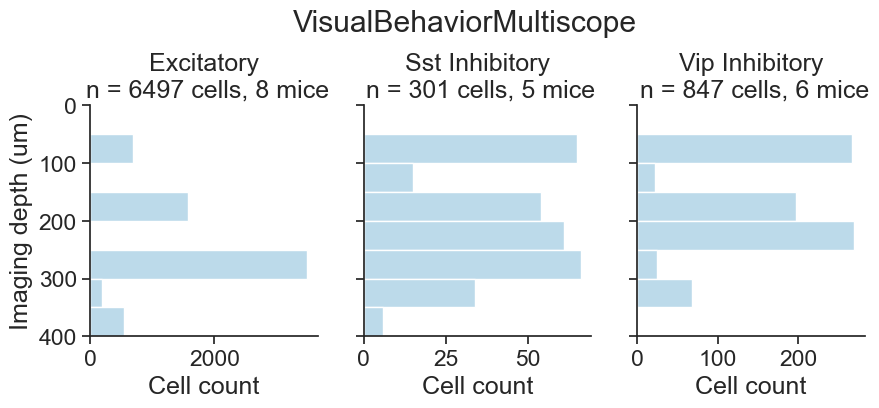

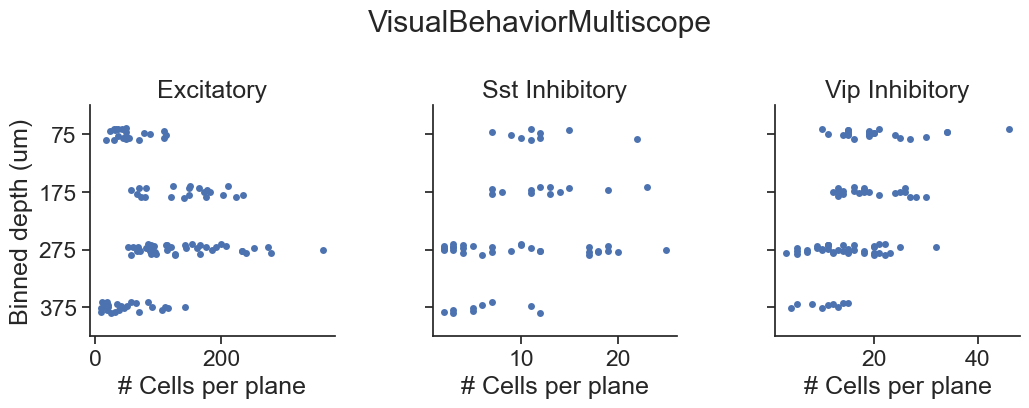

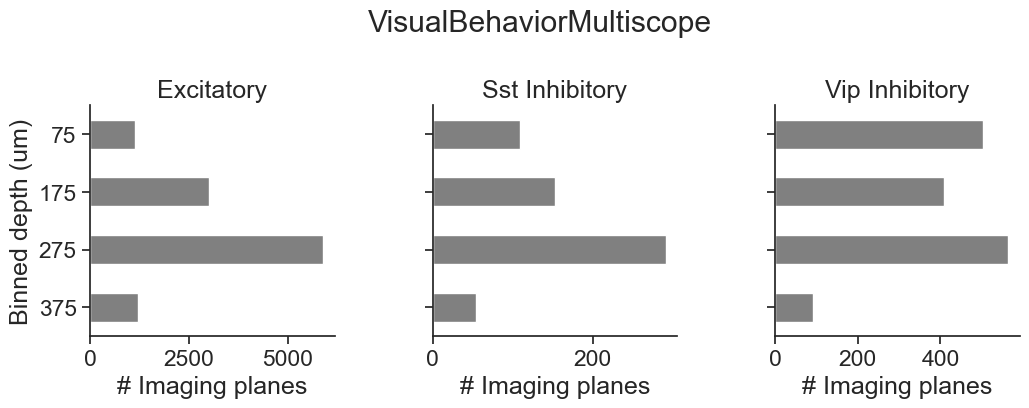

In [38]:
cells = platform_cells_table.drop_duplicates('cell_specimen_id')
cells = cells[cells.project_code=='VisualBehaviorMultiscope']
suptitle = 'VisualBehaviorMultiscope'
ppf.plot_cell_count_by_depth(cells, suptitle=suptitle, save_dir=save_dir, folder=folder, ax=None)

tmp = platform_cells_table.copy()
tmp = tmp[tmp.project_code=='VisualBehaviorMultiscope']
ppf.plot_n_cells_per_plane_by_depth(tmp, suptitle=suptitle, save_dir=save_dir, folder=folder, ax=None)
ppf.plot_n_planes_per_depth(tmp, suptitle=suptitle, save_dir=save_dir, folder=folder, ax=None)


#### Platform dataset

array([<AxesSubplot:title={'center':'Excitatory'}, xlabel='# Imaging planes', ylabel='Binned depth (um)'>,
       <AxesSubplot:title={'center':'Sst Inhibitory'}, xlabel='# Imaging planes'>,
       <AxesSubplot:title={'center':'Vip Inhibitory'}, xlabel='# Imaging planes'>],
      dtype=object)

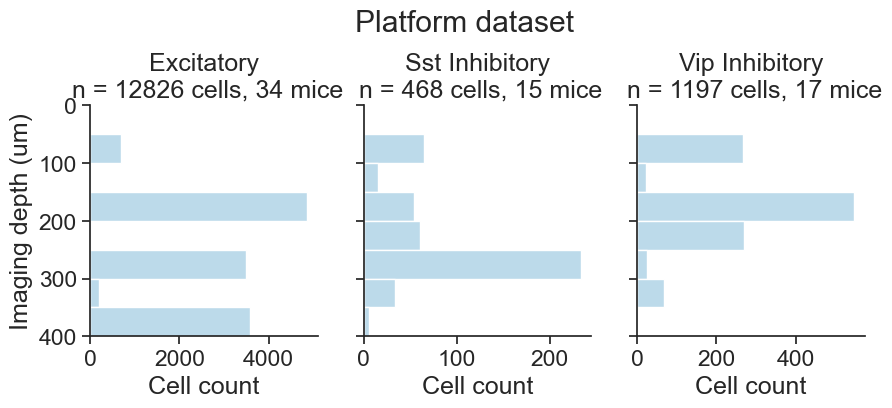

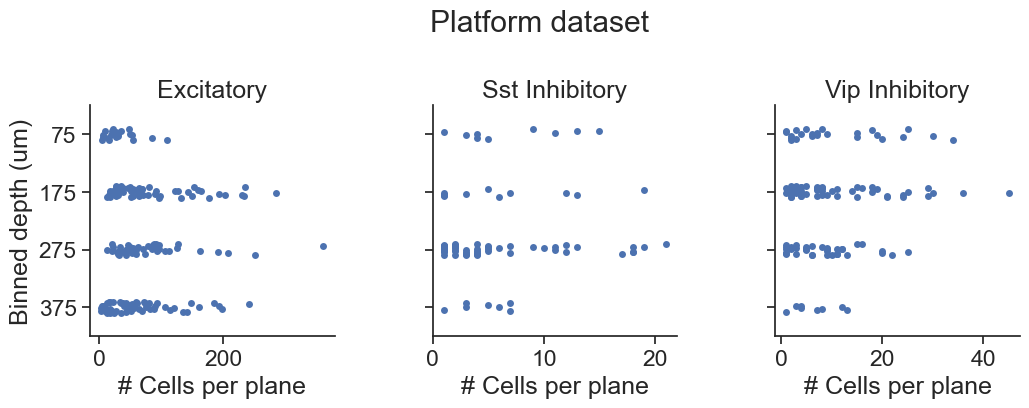

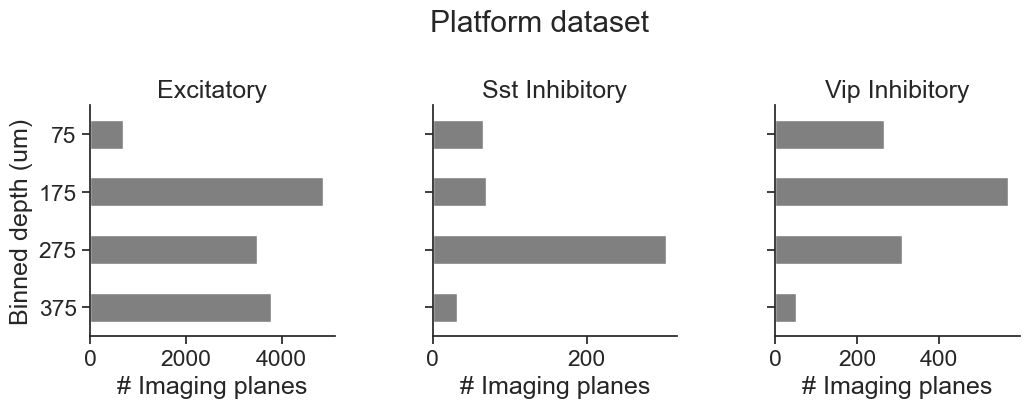

In [39]:
cells = platform_cells_table.drop_duplicates('cell_specimen_id')
suptitle = 'Platform dataset'

ppf.plot_cell_count_by_depth(cells, suptitle=suptitle, save_dir=save_dir, folder=folder, ax=None)

ppf.plot_n_cells_per_plane_by_depth(cells, suptitle=suptitle, save_dir=save_dir, folder=folder, ax=None)
ppf.plot_n_planes_per_depth(cells, suptitle=suptitle, save_dir=save_dir, folder=folder, ax=None)


#### Full dataset

1670
107133


array([<AxesSubplot:title={'center':'Excitatory'}, xlabel='# Imaging planes', ylabel='Binned depth (um)'>,
       <AxesSubplot:title={'center':'Sst Inhibitory'}, xlabel='# Imaging planes'>,
       <AxesSubplot:title={'center':'Vip Inhibitory'}, xlabel='# Imaging planes'>],
      dtype=object)

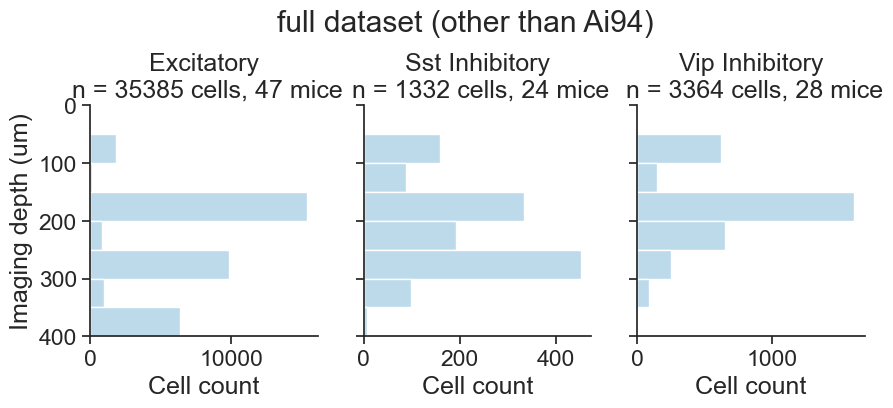

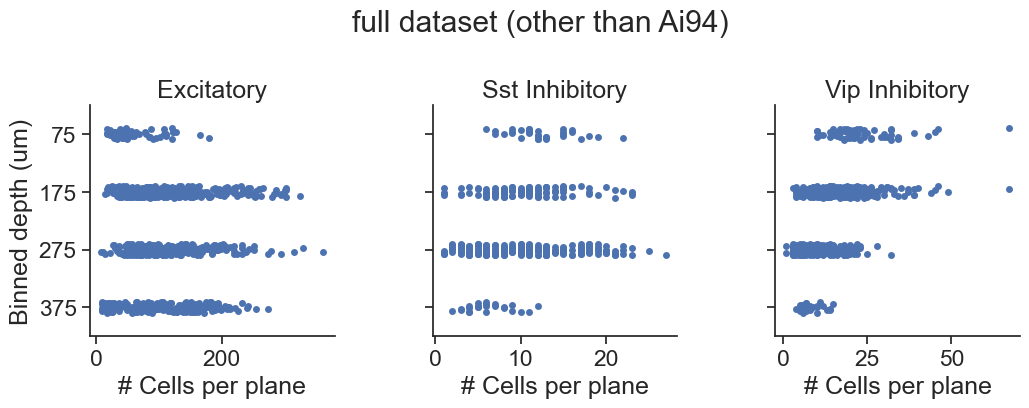

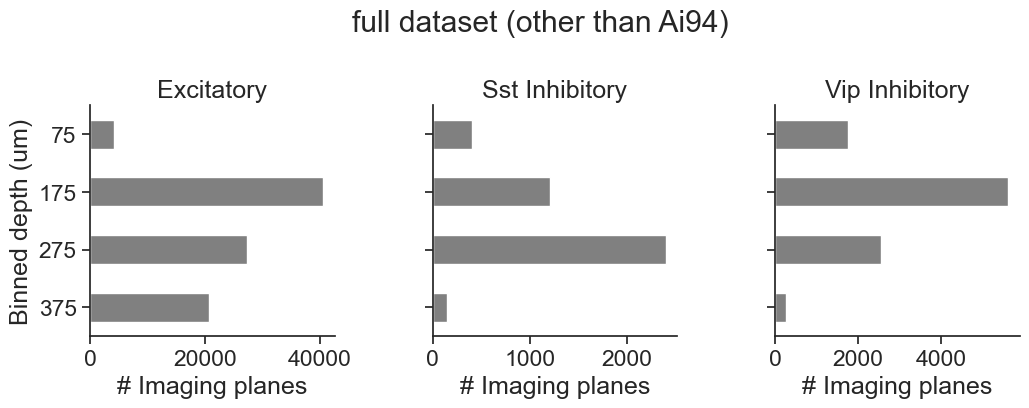

In [40]:
cells = ophys_cells_table.drop_duplicates('cell_specimen_id')
cells = cells[cells.reporter_line.str.contains('Ai94')==False]
print(len(cells.ophys_experiment_id.unique()))
suptitle = 'full dataset (other than Ai94)'

ppf.plot_cell_count_by_depth(cells, suptitle=suptitle, save_dir=save_dir, folder=folder, ax=None)

tmp = ophys_cells_table.copy()
tmp = tmp[tmp.reporter_line.str.contains('Ai94')==False]
print(len(tmp))

ppf.plot_n_cells_per_plane_by_depth(tmp, suptitle=suptitle, save_dir=save_dir, folder=folder, ax=None)
ppf.plot_n_planes_per_depth(tmp, suptitle=suptitle, save_dir=save_dir, folder=folder, ax=None)


#### vertically organized, with all areas

1670


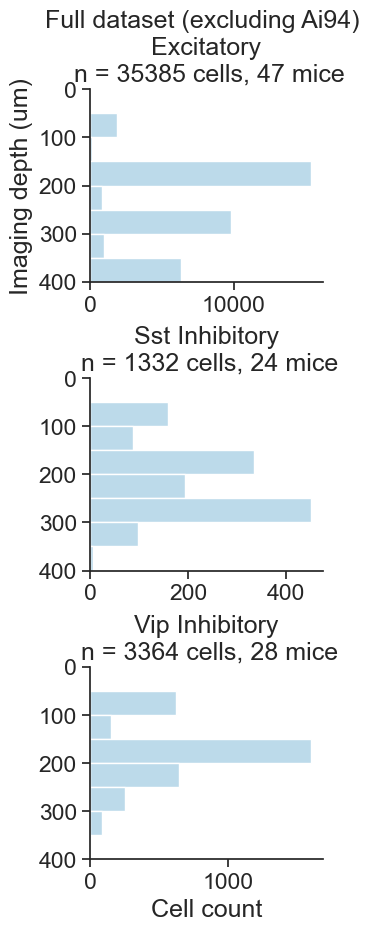

In [41]:
cells = ophys_cells_table.drop_duplicates('cell_specimen_id')
cells = cells[cells.reporter_line.str.contains('Ai94')==False]
print(len(cells.ophys_experiment_id.unique()))
suptitle = 'Full dataset (excluding Ai94)'
suffix = '_full_dataset'
ppf.plot_cell_count_by_depth(cells, project_code=None, suptitle=suptitle, horiz=False,
                             save_dir=save_dir, folder=folder, suffix=suffix, ax=None);

#### per project code

In [42]:
project_code = 'VisualBehavior'
proj_cells = cells[cells.project_code==project_code]

proj_cells.groupby(['cre_line', 'imaging_depth']).count()

ophys_experiment_id  cell_specimen_id  \
cre_line          imaging_depth                                          
Slc17a7-IRES2-Cre 175                           2796              2796   
                  375                           3125              3125   
Sst-IRES-Cre      275                            116               116   
                  290                             23                23   
Vip-IRES-Cre      175                            379               379   

                                 behavior_session_id  ophys_session_id  \
cre_line          imaging_depth                                          
Slc17a7-IRES2-Cre 175                           2796              2796   
                  375                           3125              3125   
Sst-IRES-Cre      275                            116               116   
                  290                             23                23   
Vip-IRES-Cre      175                            379               379   

                                 ophys_container_id  mouse_id  indicator  \
cre_line          imaging_depth                                            
Slc17a7-IRES2-Cre 175                          2796      2796       2796   
                  375                          3125      3125       3125   
Sst-IRES-Cre      275                           116       116        116   
                  290                            23        23         23   
Vip-IRES-Cre      175                           379       379        379   

                                 full_genotype  driver_line  reporter_line  \
cre_line          imaging_depth                                              
Slc17a7-IRES2-Cre 175                     2796         2796           2796   
                  375                     3125         3125           3125   
Sst-IRES-Cre      275                      116          116            116   
                  290                       23           23             23   
Vip-IRES-Cre      175                      379          379            379   

                                 ...  layer  area_layer  date  first_novel  \
cre_line          imaging_depth  ...                                         
Slc17a7-IRES2-Cre 175            ...   2796        2796  2796         2796   
                  375            ...   3125        3125  3125         3125   
Sst-IRES-Cre      275            ...    116         116   116          116   
                  290            ...     23          23    23           23   
Vip-IRES-Cre      175            ...    379         379   379          379   

                                 n_relative_to_first_novel  last_familiar  \
cre_line          imaging_depth                                             
Slc17a7-IRES2-Cre 175                                 2796           2796   
                  375                                 2373           3125   
Sst-IRES-Cre      275                                  116            116   
                  290                                   23             23   
Vip-IRES-Cre      175                                  299            379   

                                 last_familiar_active  second_novel  \
cre_line          imaging_depth                                       
Slc17a7-IRES2-Cre 175                            2796          2796   
                  375                            3125          3125   
Sst-IRES-Cre      275                             116           116   
                  290                              23            23   
Vip-IRES-Cre      175                             379           379   

                                 second_novel_active  experience_exposure  
cre_line          imaging_depth                                            
Slc17a7-IRES2-Cre 175                           2796                 2796  
                  375                           3125                 3125  
Sst-IRES-Cre      275     

336


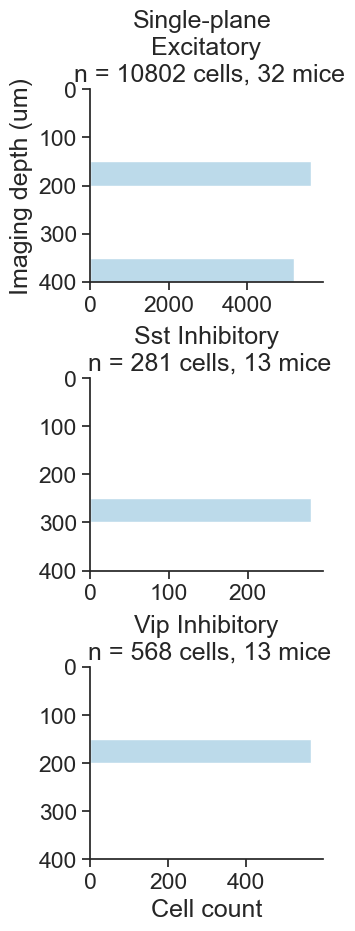

In [43]:
cells = ophys_cells_table.drop_duplicates('cell_specimen_id')
cells = cells[cells.reporter_line.str.contains('Ai94')==False]
project_codes = ['VisualBehavior', 'VisualBehaviorTask1B']
proj_cells = cells[cells.project_code.isin(project_codes)]
project_code = 'Single-plane'
print(len(proj_cells.ophys_experiment_id.unique()))
suptitle = project_code
suffix = '_'+project_code
ppf.plot_cell_count_by_depth(proj_cells, project_code=project_code, suptitle=suptitle, horiz=False,
                            save_dir=save_dir, folder=folder, suffix=suffix, ax=None);

In [44]:
ophys_cells_table.project_code.unique()

array(['VisualBehavior', 'VisualBehaviorMultiscope',
       'VisualBehaviorTask1B', 'VisualBehaviorMultiscope4areasx2d'],
      dtype=object)

163
173
784
550


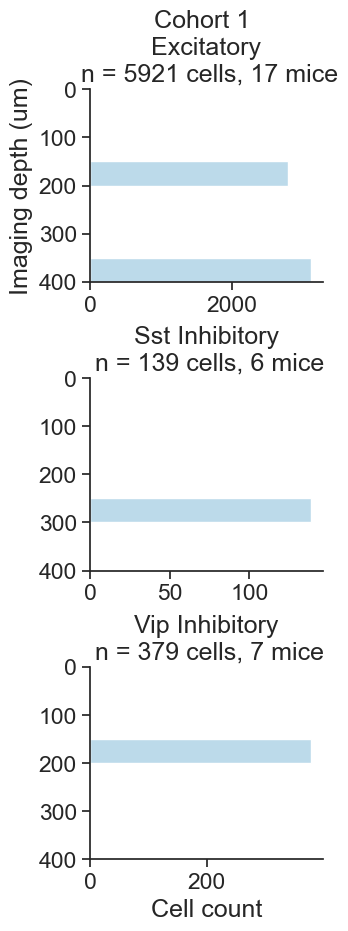

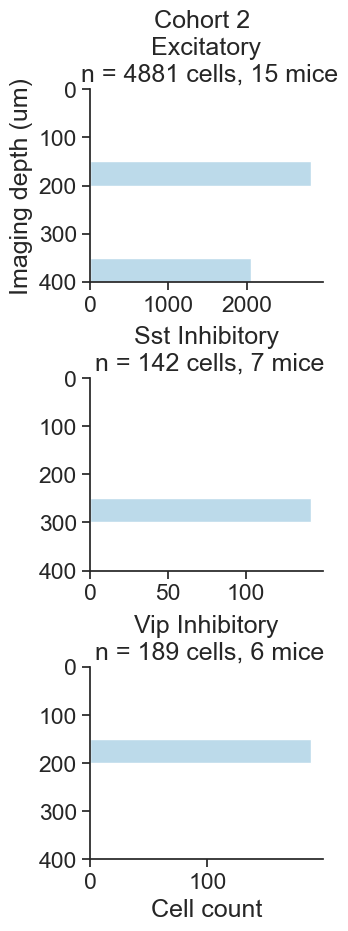

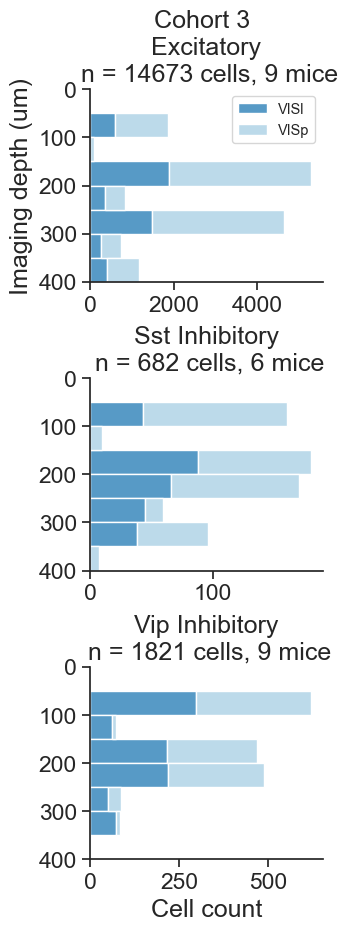

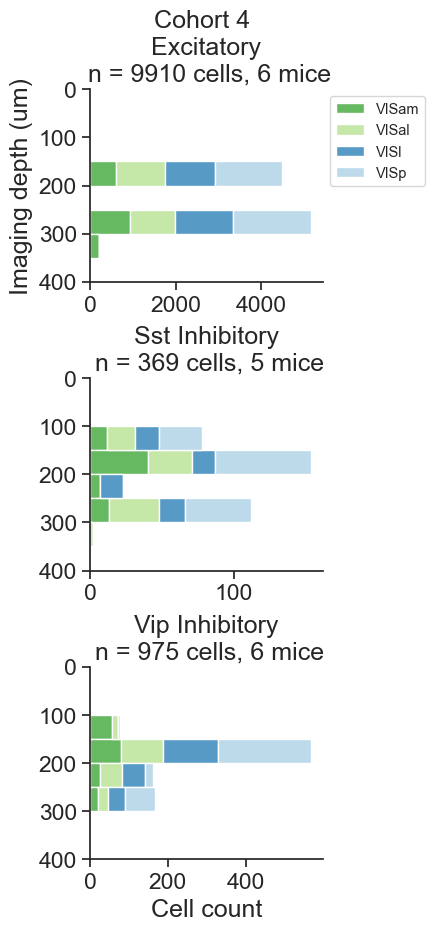

In [45]:
cells = ophys_cells_table.drop_duplicates('cell_specimen_id')
cells = cells[cells.reporter_line.str.contains('Ai94')==False]

project_codes = ophys_cells_table.project_code.unique()
project_codes = ['VisualBehavior', 'VisualBehaviorTask1B', 'VisualBehaviorMultiscope', 'VisualBehaviorMultiscope4areasx2d']

for i, project_code in enumerate(project_codes): 
    proj_cells = cells[cells.project_code==project_code]
    print(len(proj_cells.ophys_experiment_id.unique()))
    suptitle = 'Cohort '+str(i+1)
    suffix = '_'+project_code
    ppf.plot_cell_count_by_depth(proj_cells, project_code=project_code, suptitle=suptitle, horiz=False,
                                save_dir=save_dir, folder=folder, suffix=suffix, ax=None);

### Platform dataset only

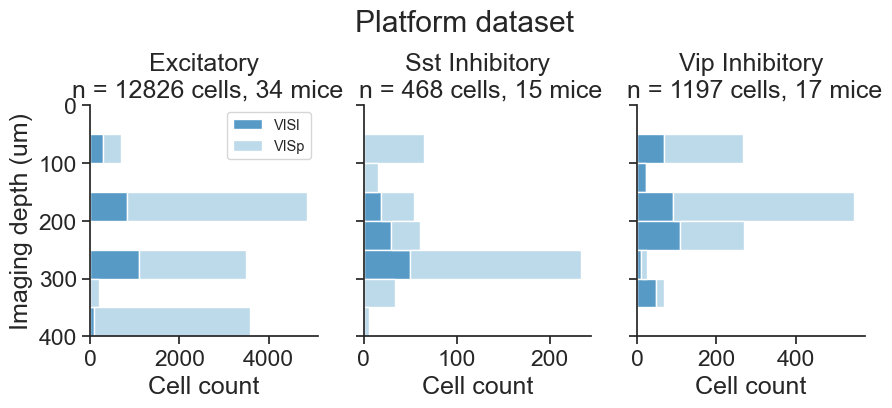

In [46]:
cells = platform_cells_table.drop_duplicates('cell_specimen_id')

suptitle = 'Platform dataset'
suffix = '_platform_cells_table'
ppf.plot_cell_count_by_depth(cells, project_code='VisualBehaviorMultiscope', suptitle=suptitle, horiz=True,
                            save_dir=save_dir, folder=folder, suffix=suffix, ax=None);

In [47]:
ophys_cells_table.project_code.unique()

array(['VisualBehavior', 'VisualBehaviorMultiscope',
       'VisualBehaviorTask1B', 'VisualBehaviorMultiscope4areasx2d'],
      dtype=object)

70
250
63


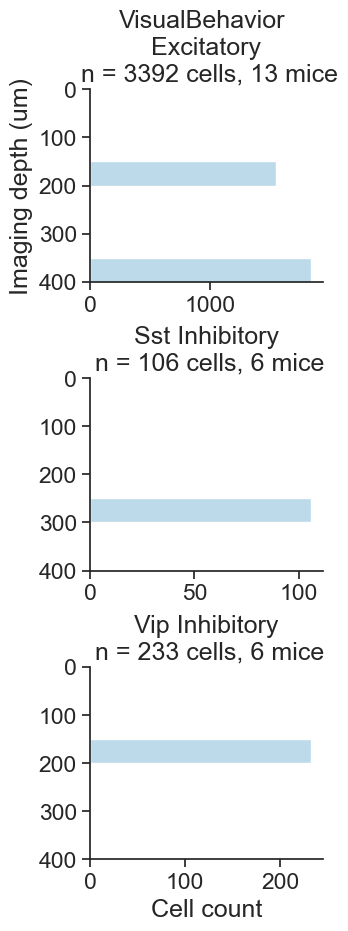

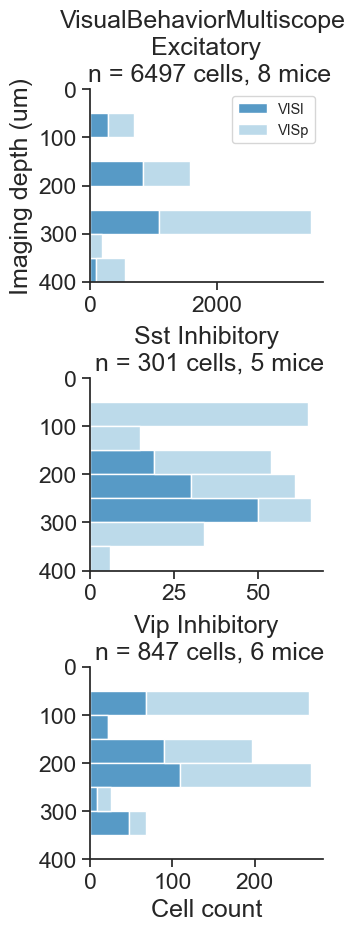

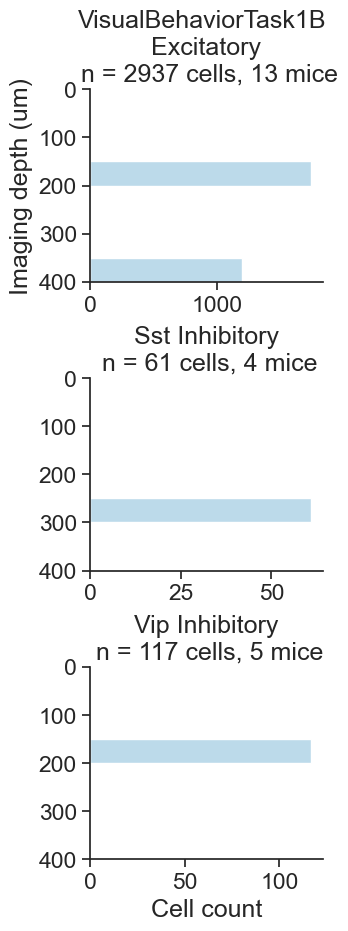

In [48]:

cells = platform_cells_table.drop_duplicates('cell_specimen_id')
cells = cells[cells.reporter_line.str.contains('Ai94')==False]
for project_code in platform_cells_table.project_code.unique(): 
    proj_cells = cells[cells.project_code==project_code]
    print(len(proj_cells.ophys_experiment_id.unique()))
    suptitle = project_code
    suffix = '_'+project_code
    ppf.plot_cell_count_by_depth(proj_cells, project_code=project_code, suptitle=suptitle, horiz=False,
                                save_dir=save_dir, folder=folder, suffix=suffix, ax=None);

#### full platform dataset

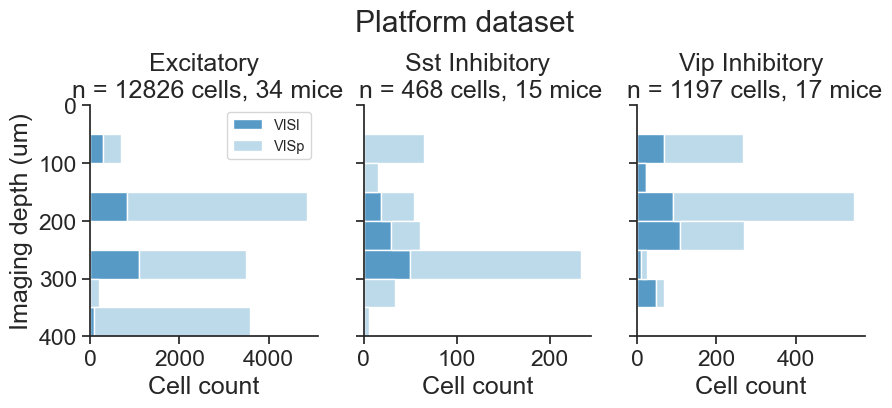

In [49]:

cells = platform_cells_table.drop_duplicates('cell_specimen_id')

suptitle = 'Platform dataset'
suffix = '_platform_cells_table'
ppf.plot_cell_count_by_depth(cells, project_code='VisualBehaviorMultiscope', suptitle=suptitle, horiz=True,
                            save_dir=save_dir, folder=folder, suffix=suffix, ax=None);

#### Check depths per cre line across all acquired datasets

In [50]:
filepath = r"\\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_cache_new\all_acquired_vb_ophys_experiments.xlsx"

df = pd.read_excel(filepath)
df.head()

,lims_workflow_state,ophys_experiment_id,ophys_session_id,mouse_id,full_genotype,project_code,date_of_acquisition,rig_id,operator,name,imaging_depth,targeted_structure,notes,qc_submitted,qc_status
0,qc,1128621854,1128492023,582904,Sst-IRES-Cre;Ai148,VisualBehaviorMultiscope4areasx2d,09/15/2021 04:46,MESO.2,sams,20210915_582904_ophys1_2_VISam_1110_-1639_180,180.0,VISam,NaN,NaN,missing
1,qc,1128621852,1128492023,582904,Sst-IRES-Cre;Ai148,VisualBehaviorMultiscope4areasx2d,09/15/2021 04:46,MESO.2,sams,20210915_582904_ophys1_2_VISam_1110_-1639_110,110.0,VISam,NaN,NaN,missing
2,qc,1128621851,1128492023,582904,Sst-IRES-Cre;Ai148,VisualBehaviorMultiscope4areasx2d,09/15/2021 04:46,MESO.2,sams,20210915_582904_ophys1_2_VISal_-134_332_180,180.0,VISal,NaN,NaN,missing
3,qc,1128621849,1128492023,582904,Sst-IRES-Cre;Ai148,VisualBehaviorMultiscope4areasx2d,09/15/2021 04:46,MESO.2,sams,20210915_582904_ophys1_2_VISal_-134_332_95,95.0,VISal,NaN,NaN,missing
4,qc,1128621848,1128492023,582904,Sst-IRES-Cre;Ai148,VisualBehaviorMultiscope4areasx2d,09/15/2021 04:46,MESO.2,sams,20210915_582904_ophys1_2_VISl_-999_471_225,225.0,VISl,NaN,NaN,missing


In [51]:
df.full_genotype.unique()

array(['Sst-IRES-Cre;Ai148', 'Vip-IRES-Cre;Ai148',
       'Slc17a7-IRES2-Cre;Camk2a-tTA;Ai93', 'Ai148',
       'Slc17a7-IRES2-Cre;Camk2a-tTA;Ai94',
       'Chat-IRES-Cre-neo;Chrm2-tdT;Ai162', 'Slc6a4-CreERT2_EZ13;Ai162',
       'Cux2-CreERT2;Camk2a-tTA;Ai93'], dtype=object)

In [52]:
genotypes = ['Sst-IRES-Cre;Ai148', 'Vip-IRES-Cre;Ai148']

df[df.full_genotype.isin(genotypes)].groupby(['full_genotype', 'imaging_depth']).count()

lims_workflow_state  ophys_experiment_id  \
full_genotype      imaging_depth                                             
Sst-IRES-Cre;Ai148 18.0                             1                    1   
                   27.0                             1                    1   
                   30.0                             1                    1   
                   45.0                             1                    1   
                   46.0                             1                    1   
...                                               ...                  ...   
Vip-IRES-Cre;Ai148 360.0                            1                    1   
                   375.0                            2                    2   
                   380.0                            1                    1   
                   381.0                            1                    1   
                   395.0                            1                    1   

                                  ophys_session_id  mouse_id  project_code  \
full_genotype      imaging_depth                                             
Sst-IRES-Cre;Ai148 18.0                          1         1             1   
                   27.0                          1         1             1   
                   30.0                          1         1             1   
                   45.0                          1         1             1   
                   46.0                          1         1             1   
...                                            ...       ...           ...   
Vip-IRES-Cre;Ai148 360.0                         1         1             1   
                   375.0                         2         2             2   
                   380.0                         1         1             1   
                   381.0                         1         1             1   
                   395.0                         1         1             1   

                                  date_of_acquisition  rig_id  operator  name  \
full_genotype      imaging_depth                                                
Sst-IRES-Cre;Ai148 18.0                             1       1         1     1   
                   27.0                             1       1         1     1   
                   30.0                             1       1         1     1   
                   45.0                             1       1         1     1   
                   46.0                             1       1         1     1   
...                                               ...     ...       ...   ...   
Vip-IRES-Cre;Ai148 360.0                            1       1         1     1   
                   375.0                            2       2         2     2   
                   380.0                            1       1         1     1   
                   381.0                            1       1         1     1   
                   395.0                            1       1         1     1   

                                  targeted_structure  notes  qc_submitted  \
full_genotype      imaging_depth                                            
Sst-IRES-Cre;Ai148 18.0                            1      0             0   
                   27.0                            1      0             0   
                   30.0                            1      0             0   
                   45.0                            1      0             0   
                   46.0                            1      0             0   
...                                              ...    ...           ...   
Vip-IRES-Cre;Ai148 360.0                           1      0             0   
                   375.0                           2      0             0   
                   380.0                           1      0             0   
                   381.0                           1      0             0   
                   395.0  

In [53]:
def add_cell_type_column(df):
    """
    adds a column with abbreviated version of cre_line, i.e. Vip, Sst, Exc
    """
    cre_indices = df[df.full_genotype == 'Vip-IRES-Cre;Ai148'].index.values
    df.loc[cre_indices, 'cell_type'] = 'Vip Inhibitory'

    cre_indices = df[df.full_genotype == 'Sst-IRES-Cre;Ai148'].index.values
    df.loc[cre_indices, 'cell_type'] = 'Sst Inhibitory'

    return df

In [54]:
def plot_expt_count_by_depth_tmp(expts_table, suptitle=None, save_dir=None, folder=None, ax=None): 
    
    colors = [sns.color_palette()[9],sns.color_palette()[0]]
    if ax is None: 
        figsize = (12, 3)
        fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)
    for i, cell_type in enumerate(utils.get_cell_types()):
        ax[i] = sns.histplot(data=expts_table[expts_table.cell_type==cell_type], bins=10, y='imaging_depth', 
                            palette=colors, multiple='stack', stat='count', ax=ax[i])
        title = cell_type+'\n'+str(len(expts_table[expts_table.cell_type==cell_type]))+' cells, '+str(len(expts_table[expts_table.cell_type==cell_type].mouse_id.unique()))+' mice'
        ax[i].set_title(title)
        ax[i].invert_yaxis()
        ax[i].set_ylim(400, 50)
        ax[i].set_xlabel('Experiment count')
        ax[i].set_ylabel('')
    ax[0].set_ylabel('Imaging depth (um)')
    plt.subplots_adjust(wspace=0.3)
    plt.suptitle(suptitle, x=0.5, y=1.2)

    if save_dir: 
        utils.save_figure(fig, figsize, save_dir, folder, 'expt_count_by_depth_'+suptitle)
    return ax

C:\Users\marinag\AppData\Local\Temp\ipykernel_5724\2927693027.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax[i] = sns.histplot(data=expts_table[expts_table.cell_type==cell_type], bins=10, y='imaging_depth',
C:\Users\marinag\AppData\Local\Temp\ipykernel_5724\2927693027.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax[i] = sns.histplot(data=expts_table[expts_table.cell_type==cell_type], bins=10, y='imaging_depth',
C:\Users\marinag\AppData\Local\Temp\ipykernel_5724\2927693027.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax[i] = sns.histplot(data=expts_table[expts_table.cell_type==cell_type], bins=10, y='imaging_depth',


array([<AxesSubplot:title={'center':'Excitatory\n0 cells, 0 mice'}, xlabel='Experiment count', ylabel='Imaging depth (um)'>,
       <AxesSubplot:title={'center':'Sst Inhibitory\n1374 cells, 46 mice'}, xlabel='Experiment count'>,
       <AxesSubplot:title={'center':'Vip Inhibitory\n1594 cells, 39 mice'}, xlabel='Experiment count'>],
      dtype=object)

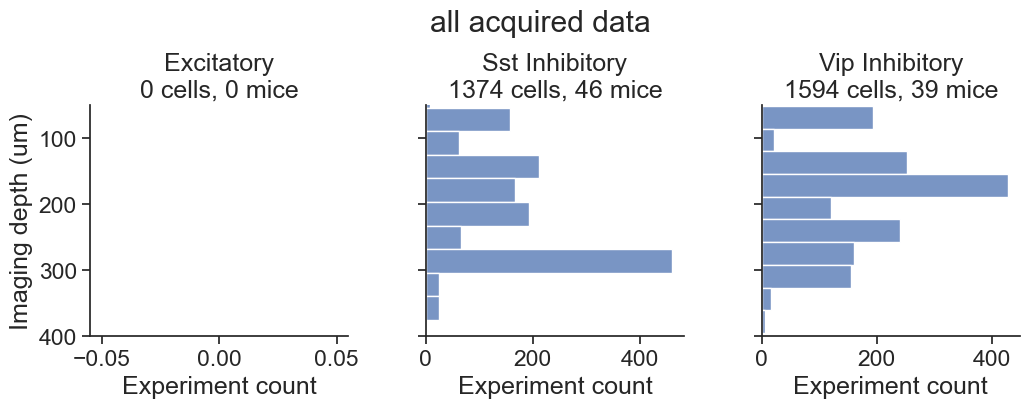

In [55]:
df = add_cell_type_column(df)
plot_expt_count_by_depth_tmp(df, suptitle='all acquired data', save_dir=None, folder=None, ax=None)

## Plot data for one mouse

In [56]:
# mice with a good session sequence 
mouse_ids = [484627, 456917, 467953, 479839, 461946, 459777, 456916, 
            485688, 489066, 467954, 523927, 412036, 445002, 436662,
            436662, 425496, 412366,]
print(np.sort(mouse_ids))

# this is the one from the example figure with all FOVs
mouse_id = 449653



[412036 412366 425496 436662 436662 445002 456916 456917 459777 461946
 467953 467954 479839 484627 485688 489066 523927]


In [57]:
# mice with 7-8 planes present across all days 
mouse_ids = [449653, 451787, 453988, 479839, 484627, 485152, ]

# mice with a good session order and all / most planes 
most_perfect_mice = [449653, # Vip (from example), has 7 planes, 5 sessions out of order but could be rearranged (missing novel passive)
                    453988, # Vip, same conditions as the mouse above
                    484627, # Slc,  has all 8 planes, sessions in perfect order
                    479839, # Slc, has all 8 planes, sessions slightly out of order but could be rearranged
                    485152, # Slc, has 7 planes, slightly out of order
                    ]
# count number of experiments per session for each mouse
# experiments_table[(experiments_table.mouse_id.isin(mouse_ids))].groupby(['mouse_id', 'cre_line', 'date_of_acquisition','session_type']).count()

In [58]:
# #count number of experiments per session for each mouse 
# experiments_table[(experiments_table.project_code=='VisualBehaviorMultiscope') & 
#                   (experiments_table.cre_line=='Sst-IRES-Cre')].groupby(['mouse_id', 'date_of_acquisition']).count()[:50]

### Get cell response dfs

In [59]:
data_type = 'dff'

interpolate = True
output_sampling_rate = 30

inclusion_criteria = 'all'

In [60]:
# # params for stim response df creation
# event_type = 'all'

# # params for mean response df creation
# conditions = ['cell_specimen_id', 'is_change']

# multi_session_df = loading.get_multi_session_df_for_conditions(data_type, event_type, conditions, inclusion_criteria, 
#                                                         interpolate=interpolate, output_sampling_rate=output_sampling_rate, 
#                                                          epoch_duration_mins=None)

# # limit to changes, convert experience level and merge with cluster IDs
# change_mdf = multi_session_df[multi_session_df.is_change==True]

# # limit to non-changes, convert experience level and merge with cluster IDs
# image_mdf = multi_session_df[(multi_session_df.is_change==False)]

### Save dataset dict for selected containers 

In [61]:
# mouse_id = mouse_ids[1]
# mouse_id = 484627 # Slc example - perfect but takes too much memory
mouse_id = 449653 # Vip example - incomplete
mouse_expts = experiments_table[experiments_table.mouse_id==mouse_id].sort_values(by=['date_of_acquisition', 'targeted_structure', 'imaging_depth'])
# mouse_expts[['cre_line', 'targeted_structure', 'imaging_depth', 'session_type', 'date_of_acquisition']]

In [62]:
# # mouse_id = 484627 # Slc example - perfect but takes too much memory
# mouse_id = 449653 # Vip example - incomplete

# mouse_expts = experiments_table[experiments_table.mouse_id==mouse_id].sort_values(by=['date_of_acquisition', 'targeted_structure', 'imaging_depth'])
# ophys_container_ids = mouse_expts.ophys_container_id.unique()


# dataset_dict = loading.get_dataset_dict_for_containers(ophys_container_ids, 
#                                                             mouse_expts, 
#                                                             dataset_dict=None)

##### Plot matched ROI outlines

In [63]:
def plot_max_intensity_projection(dataset, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    max_projection = dataset.max_projection.data
    ax.imshow(max_projection, cmap='gray', vmax=np.percentile(max_projection, 99))
    ax.axis('off')
    return ax

def plot_roi_mask_outlines(dataset, cell_specimen_ids=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax = plot_max_intensity_projection(dataset, ax=ax)
    cell_specimen_table = dataset.cell_specimen_table.copy()
    if cell_specimen_ids is None:
        cell_specimen_ids = cell_specimen_table.index.values
    if len(cell_specimen_table) > 0:
        for cell_specimen_id in cell_specimen_ids:
            mask = cell_specimen_table.loc[cell_specimen_id].roi_mask
            ax.contour(mask, levels=0, colors=['red'], linewidths=[0.5])
    ax.axis('off')
    return ax

In [64]:
# ophys_container_id = ophys_containers[0]
# matched_cells = matched_cells_table[matched_cells_table.ophys_container_id==ophys_container_id].cell_specimen_id.unique()

# expt_ids = list(dataset_dict[ophys_container_id].keys())
# dataset = dataset_dict[ophys_container_id][expt_ids[0]]

# pse.plot_roi_mask_outlines(dataset, cell_specimen_ids=matched_cells, ax=None)

In [65]:
# ophys_experiment_id = 808621034
# dataset = loading.get_ophys_dataset(ophys_experiment_id)

# trials = dataset.trials.copy()
# start_times = trials[trials.is_change].start_time.values
# start_time = start_times[10]

# ppf.plot_behavior_and_physio_timeseries_stacked(dataset, start_time=628, duration_seconds=20, save_dir=save_dir, ax=None)

### Plot all FOVs for one mouse 

In [66]:
tmp =  mouse_expts.copy() 
tmp = tmp[tmp.session_type=='OPHYS_4_images_B']
tmp[['mouse_id', 'targeted_structure', 'imaging_depth', 'ophys_container_id', 'prior_exposures_to_image_set', 'ophys_session_id', 'session_type']]

,mouse_id,targeted_structure,imaging_depth,ophys_container_id,prior_exposures_to_image_set,ophys_session_id,session_type
ophys_experiment_id,,,,,,,
877669826,449653,VISl,75,1018027605,0,873247524,OPHYS_4_images_B
877669822,449653,VISl,150,1018027608,0,873247524,OPHYS_4_images_B
877669819,449653,VISl,225,1018027611,0,873247524,OPHYS_4_images_B
877669824,449653,VISl,300,1018027615,0,873247524,OPHYS_4_images_B
877669817,449653,VISp,75,1018027593,0,873247524,OPHYS_4_images_B
877669811,449653,VISp,225,1018027599,0,873247524,OPHYS_4_images_B
877669815,449653,VISp,300,1018027602,0,873247524,OPHYS_4_images_B
877057357,449653,VISl,75,1018027605,1,876303107,OPHYS_4_images_B
877057351,449653,VISl,154,1018027608,1,876303107,OPHYS_4_images_B


#### Plot all FOVs

In [67]:
# # for mouse 484627
# ophys_container_ids = [1018027822, 1018027825, 1018027828, 1018027834, 1018027837, 1018027841, 1018027844]

# # ophys_session_ids = [872592724, 870352564, 871526950,
# #                      873247524, 876303107]

In [68]:
# # for mouse 449653
# ophys_container_ids = [1018027605, 1018027608, 1018027611, 1018027615, 1018027593, 1018027599, 1018027602]

# ophys_session_ids = [872592724, 870352564, 871526950,
#                      873247524, 876303107]

In [69]:
# mouse_expts = mouse_expts.sort_values(by=['date_of_acquisition', 'targeted_structure', 'imaging_depth'])
# mouse_expts[['ophys_session_id', 'date_of_acquisition', 'targeted_structure', 'imaging_depth']]

In [70]:
# ophys_container_id = mouse_expts.ophys_container_id.unique()[0]
# ophys_experiment_id = mouse_expts[(mouse_expts.ophys_container_id==ophys_container_id)].index.values[0]

# dataset = dataset_dict[ophys_container_id][ophys_experiment_id]

In [71]:
# session_id_for_area_depths = 873247524

# ppf.plot_all_planes_all_sessions_for_mouse(dataset_dict, mouse_expts, session_id_for_area_depths, 
#                                            save_dir=save_dir, folder='max_projection_images', ax=None)

#### Get traces for one session and plot

In [72]:
# mice with 7-8 planes present across all days 
mouse_ids = [449653, 451787, 453988, 479839, 484627, 485152, ]

# mice with a good session order and all / most planes 
most_perfect_mice = [449653, # Vip (from example), has 7 planes, 5 sessions out of order but could be rearranged (missing novel passive)
                    453988, # Vip, same conditions as the mouse above
                    484627, # Slc,  has all 8 planes, sessions in perfect order
                    479839, # Slc, has all 8 planes, sessions slightly out of order but could be rearranged
                    485152, # Slc, has 7 planes, slightly out of order
                    ]
# count number of experiments per session for each mouse
# experiments_table[(experiments_table.mouse_id.isin(mouse_ids))].groupby(['mouse_id', 'cre_line', 'date_of_acquisition','session_type']).count()

In [73]:
# # for mouse 449653
# mouse_id = 449653

# ophys_container_ids = [1018027605, 1018027608, 1018027611, 1018027615, 1018027593, 1018027599, 1018027602]

# ophys_session_ids = [872592724, 870352564, 871526950, 873247524, 876303107]

In [74]:
# load just one container so we dont run out of memory

# mouse_id = 484627
mouse_id = 449653
mouse_expts = experiments_table[experiments_table.mouse_id==mouse_id].sort_values(by=['date_of_acquisition', 'targeted_structure', 'imaging_depth'])
session_expts = mouse_expts[(mouse_expts.session_type=='OPHYS_4_images_B')]
ophys_container_ids = session_expts.ophys_container_id.unique()

dataset_dict = loading.get_dataset_dict_for_containers(ophys_container_ids, 
                                                            session_expts, 
                                                            dataset_dict=None)

877669826


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


877057357


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


877669822


...

c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


877669815


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


877057341


c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


In [75]:
session_expts = mouse_expts[(mouse_expts.session_type=='OPHYS_4_images_B') & (mouse_expts.experience_level=='Novel 1')]
ophys_container_ids = session_expts.ophys_container_id.unique()

session_expts[['imaging_depth', 'targeted_structure', 'session_type', 'ophys_session_id', 'experience_level']]

,imaging_depth,targeted_structure,session_type,ophys_session_id,experience_level
ophys_experiment_id,,,,,
877669826,75,VISl,OPHYS_4_images_B,873247524,Novel 1
877669822,150,VISl,OPHYS_4_images_B,873247524,Novel 1
877669819,225,VISl,OPHYS_4_images_B,873247524,Novel 1
877669824,300,VISl,OPHYS_4_images_B,873247524,Novel 1
877669817,75,VISp,OPHYS_4_images_B,873247524,Novel 1
877669811,225,VISp,OPHYS_4_images_B,873247524,Novel 1
877669815,300,VISp,OPHYS_4_images_B,873247524,Novel 1


In [76]:
all_traces, session_metadata = ppf.aggregate_traces_for_session(dataset_dict, session_expts, trace_type='dff')
session_metadata[['mouse_id', 'targeted_structure', 'imaging_depth', 'n_cells', 'container_order']]

C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:134: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  session_metadata.loc[ophys_experiment_id, 'n_cells'] = int(traces.shape[0])
C:\Users\marinag\Documents\Code\visual_behavior_analysis\visual_behavior\visualization\ophys\platform_paper_figures.py:135: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  session_metadata.loc[ophys_experiment_id, 'ophys_frame_rate'] = dataset.metadata['ophys_frame_ra

,mouse_id,targeted_structure,imaging_depth,n_cells,container_order
ophys_experiment_id,,,,,
877669826,449653,VISl,75,15.0,0.0
877669822,449653,VISl,150,13.0,1.0
877669819,449653,VISl,225,18.0,2.0
877669824,449653,VISl,300,7.0,3.0
877669817,449653,VISp,75,15.0,4.0
877669811,449653,VISp,225,12.0,5.0
877669815,449653,VISp,300,11.0,6.0


#### Plot combined

MemoryError: 

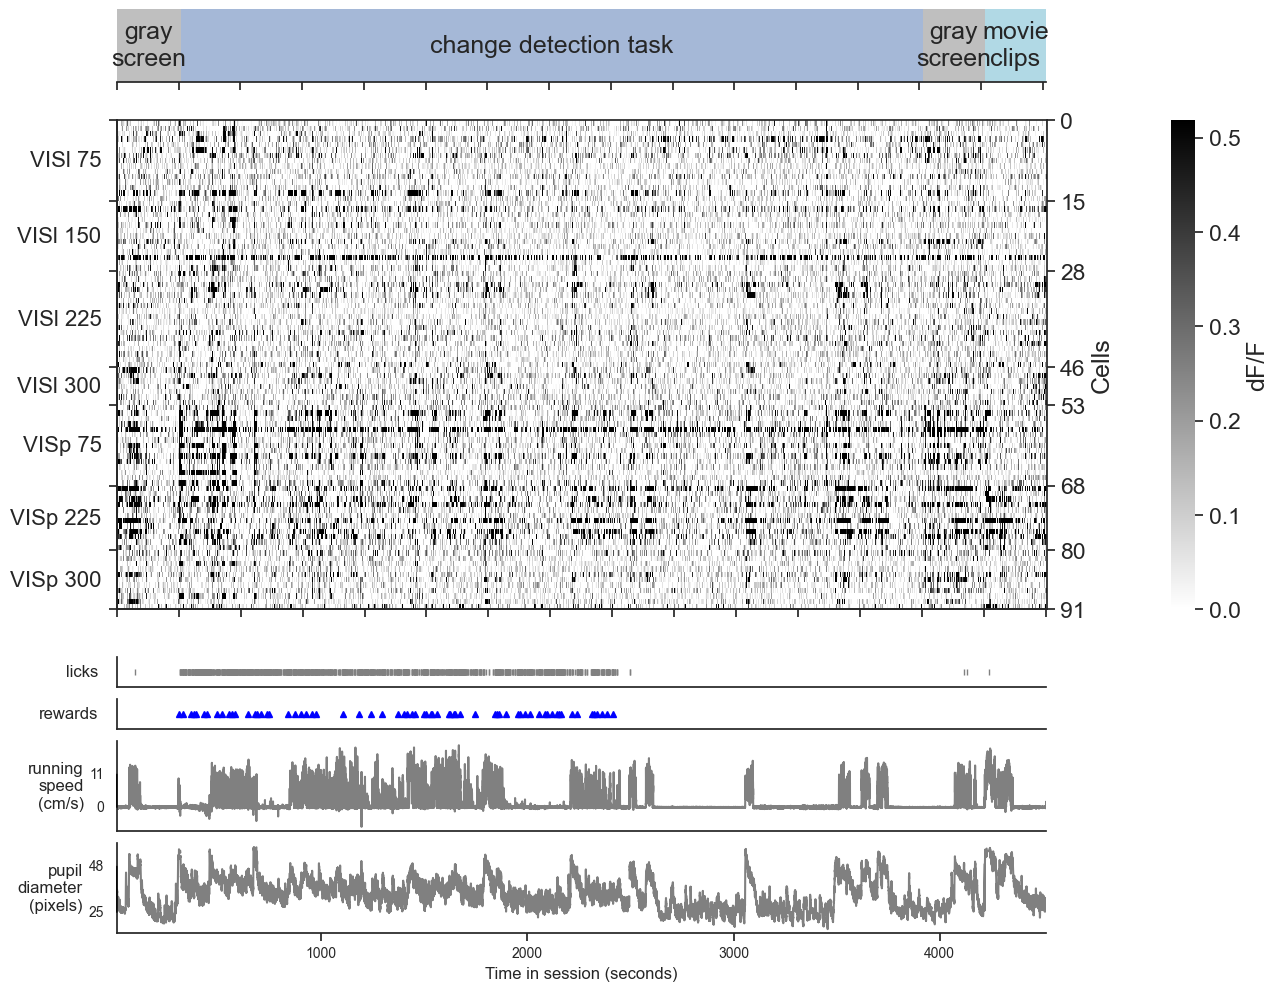

In [77]:
# get a random container from this session
ophys_container_id = session_expts.ophys_container_id.unique()[0]
ophys_experiment_id = session_expts[session_expts.ophys_container_id==ophys_container_id].index.values[0]
ophys_session_id = session_expts.ophys_session_id.unique()[0]

dataset = dataset_dict[ophys_container_id][ophys_experiment_id]
stim_table = dataset.stimulus_presentations.copy()
timestamps = dataset.ophys_timestamps.copy()
ophys_frame_rate = dataset.metadata['ophys_frame_rate']
xlim_seconds = [timestamps[0], timestamps[-1]]

# figsize = (15, 5)
# fig, ax = plt.subplots(4, 1, figsize=figsize, sharex=True, gridspec_kw={'height_ratios': [1, 1, 3, 3]})
# ax = ax.ravel()

# figsize = [10, 6]
figsize = [16, 12]
fig = plt.figure(figsize=figsize, facecolor='white')

ax = utils.placeAxesOnGrid(fig, dim=(1, 1), xspan=(0, 0.75), yspan=(0, 0.08))
ax = ppf.add_stimulus_blocks(stim_table, xlim=xlim_seconds, annotate_blocks=True, ax=ax)
ax.set_xticklabels('')
ax.set_xlabel('')

ax = utils.placeAxesOnGrid(fig, dim=(1, 1), xspan=(0, 1), yspan=(0.12, 0.65))
ax = ppf.plot_all_traces_heatmap(all_traces, session_metadata, timestamps=timestamps, cmap='gray_r', save_dir=None, ax=ax)
ax.set_xticklabels('')
ax.set_xlabel('')

ax = utils.placeAxesOnGrid(fig, dim=(4, 1), xspan=(0, 0.75), yspan=(0.7, 1), sharex=True, height_ratios=[1, 1, 3, 3])
ax = ppf.plot_behavior_timeseries_stacked(dataset, start_time=timestamps[0], xlim_seconds=xlim_seconds, 
                                     show_images=False, label_changes=False, label_omissions=False, save_dir=None, ax=ax)

folder = 'behavior_timeseries_stacked'
utils.save_figure(fig, figsize, save_dir, folder, str(mouse_id)+'_'+str(ophys_session_id)+'_traces_and_behavior_small')

KeyboardInterrupt: 

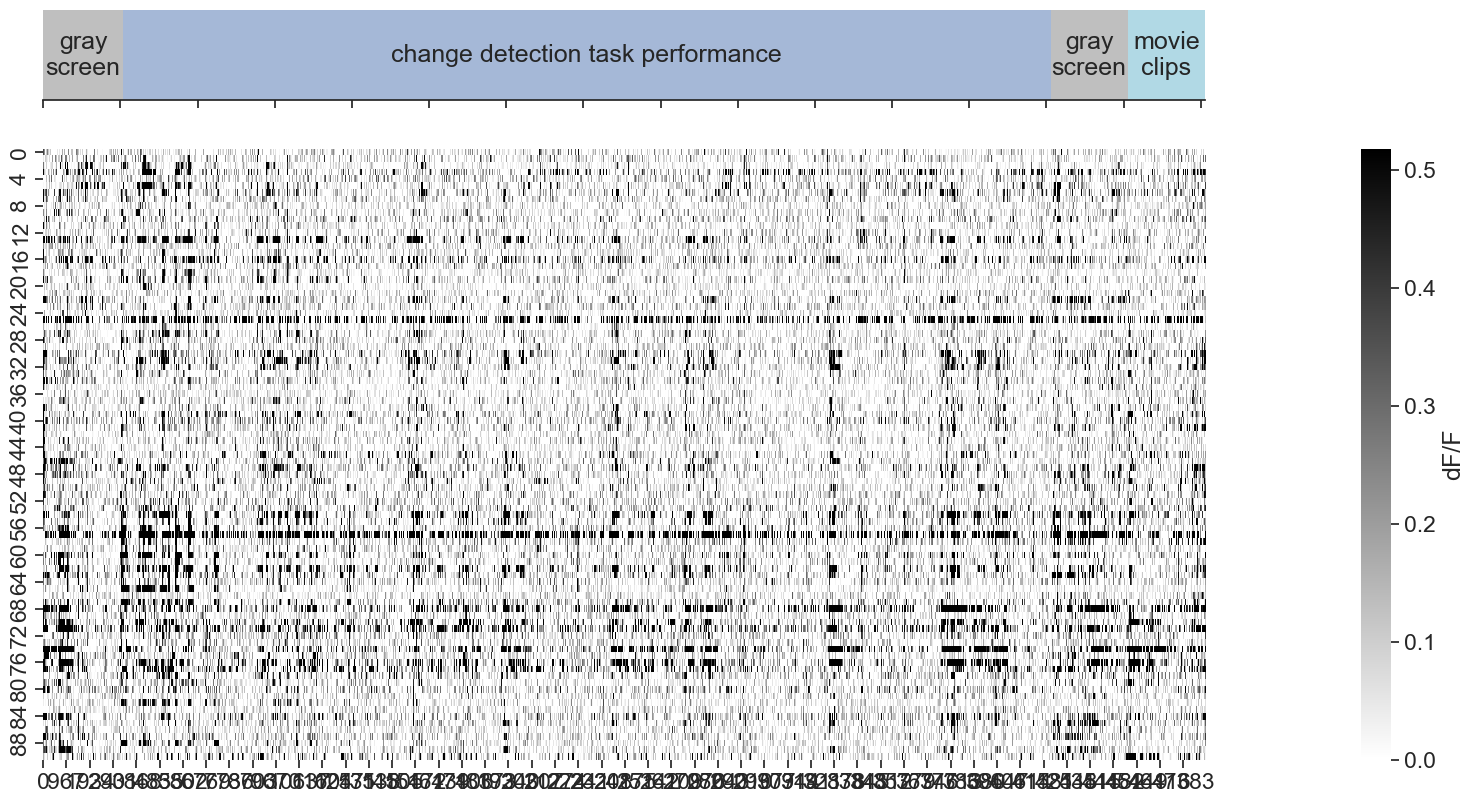

In [57]:
# get a random container from this session
ophys_container_id = session_expts.ophys_container_id.unique()[0]
ophys_experiment_id = session_expts[session_expts.ophys_container_id==ophys_container_id].index.values[0]
ophys_session_id = session_expts.ophys_session_id.unique()

dataset = dataset_dict[ophys_container_id][ophys_experiment_id]
stim_table = dataset.stimulus_presentations.copy()
timestamps = dataset.ophys_timestamps.copy()
ophys_frame_rate = dataset.metadata['ophys_frame_rate']
xlim_seconds = [timestamps[0], timestamps[-1]]

# figsize = (15, 5)
# fig, ax = plt.subplots(4, 1, figsize=figsize, sharex=True, gridspec_kw={'height_ratios': [1, 1, 3, 3]})
# ax = ax.ravel()

figsize = [20, 15]
fig = plt.figure(figsize=figsize, facecolor='white')

ax = utils.placeAxesOnGrid(fig, dim=(1, 1), xspan=(0, 0.75), yspan=(0, 0.08))
ax = ppf.add_stimulus_blocks(stim_table, xlim=xlim_seconds, annotate_blocks=True, ax=ax)
ax.set_xticklabels('')
ax.set_xlabel('')

ax = utils.placeAxesOnGrid(fig, dim=(1, 1), xspan=(0, 1), yspan=(0.12, 0.65))
ax = ppf.plot_all_traces_heatmap(all_traces, session_metadata, timestamps=timestamps, cmap='gray_r', save_dir=None, ax=ax)
ax.set_xticklabels('')
ax.set_xlabel('')

ax = utils.placeAxesOnGrid(fig, dim=(4, 1), xspan=(0, 0.75), yspan=(0.7, 1), sharex=True, height_ratios=[1, 1, 3, 3])
ax = ppf.plot_behavior_timeseries_stacked(dataset, start_time=timestamps[0], xlim_seconds=xlim_seconds, 
                                     show_images=False, label_changes=False, label_omissions=False, save_dir=None, ax=ax)

folder = 'behavior_timeseries_stacked'
utils.save_figure(fig, figsize, save_dir, folder, str(mouse_id)+'_'+str(ophys_session_id)+'_traces_and_behavior_big')

#### individual plots

<AxesSubplot:xlabel='Time in session (minutes)'>

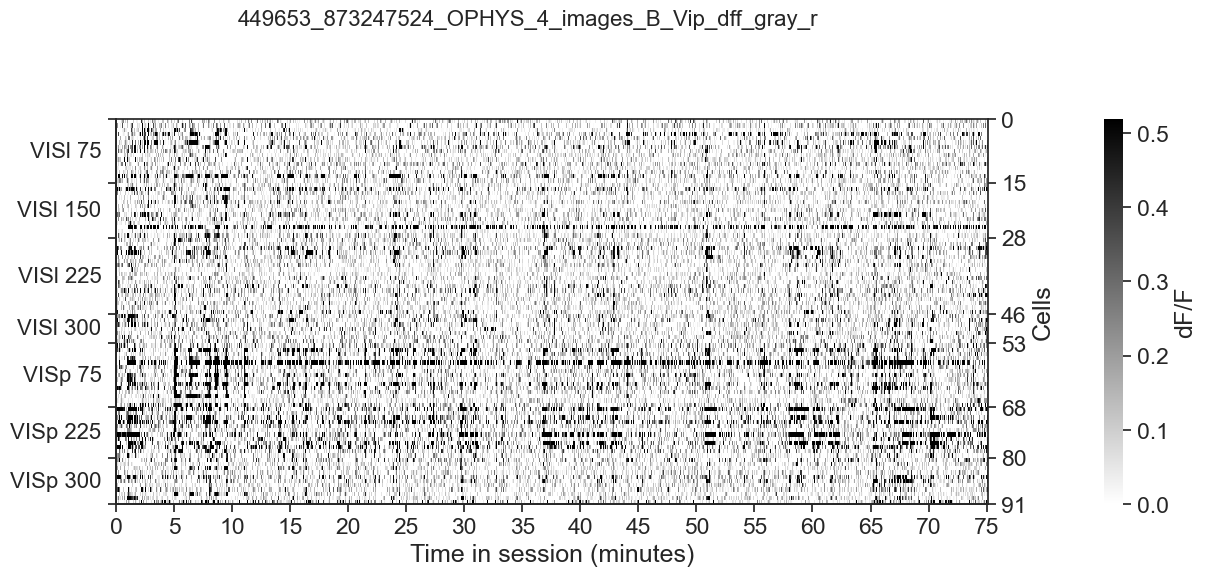

In [ ]:
# get a random container from this session
ophys_container_id = session_expts.ophys_container_id.unique()[0]
ophys_experiment_id = session_expts[session_expts.ophys_container_id==ophys_container_id].index.values[0]
dataset = dataset_dict[ophys_container_id][ophys_experiment_id]

timestamps = dataset.ophys_timestamps.copy()

ppf.plot_all_traces_heatmap(all_traces, session_metadata, timestamps=timestamps, cmap='gray_r', save_dir=save_dir, ax=None)

### plot behavior timeseries

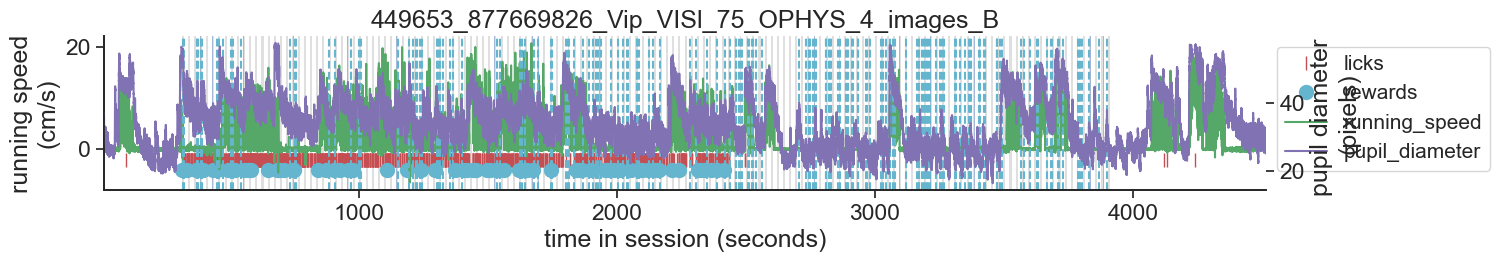

In [ ]:
# get a random container from this session
ophys_container_id = session_expts.ophys_container_id.unique()[0]
ophys_experiment_id = session_expts[session_expts.ophys_container_id==ophys_container_id].index.values[0]

dataset = dataset_dict[ophys_container_id][ophys_experiment_id]
timestamps = dataset.ophys_timestamps.copy()
# if ax is None:   
figsize = (15, 2)
fig, ax = plt.subplots(figsize=figsize)

ax = ppf.plot_behavior_timeseries(dataset, start_time=timestamps[0], xlim_seconds=[timestamps[0], timestamps[-1]], save_dir=None, ax=ax)
    

array([<AxesSubplot:title={'center':'449653_877669826_Vip_VISl_75_OPHYS_4_images_B'}, ylabel='licks'>,
       <AxesSubplot:ylabel='rewards'>,
       <AxesSubplot:ylabel='running\nspeed\n(cm/s)'>,
       <AxesSubplot:xlabel='Time in session (seconds)', ylabel='pupil\ndiameter\n(pixels)'>],
      dtype=object)

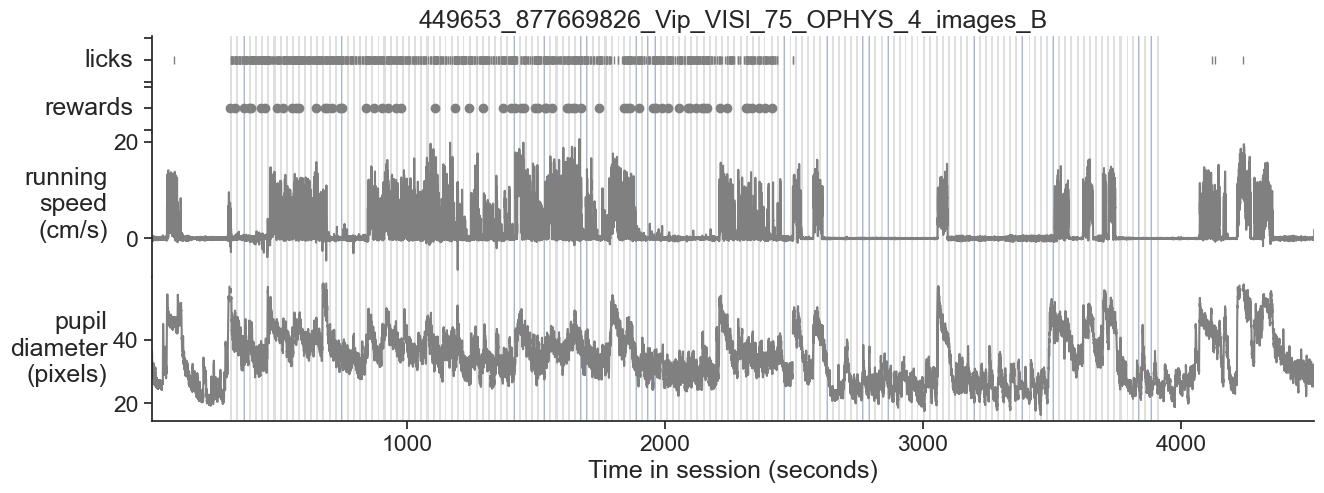

In [ ]:
ppf.plot_behavior_timeseries_stacked(dataset, start_time=timestamps[0], xlim_seconds=[timestamps[0], timestamps[-1]], 
                                     label_changes=True, label_omissions=False, save_dir=save_dir, ax=None)

#### Bar for stimulus blocks

In [ ]:
stim_table = dataset.stimulus_presentations.copy()
block_change_inds = np.where(stim_table.stimulus_block.diff())

stimulus_blocks = stim_table.loc[block_change_inds]
stimulus_blocks

,stimulus_block,stimulus_block_name,image_index,image_name,movie_frame_index,duration,start_time,end_time,start_frame,end_frame,is_change,is_image_novel,omitted,movie_repeat,flashes_since_change,trials_id,stimulus_name,is_sham_change,active
stimulus_presentations_id,,,,,,,,,,,,,,,,,,,
0,0,initial_gray_screen_5min,-99,NaN,-99,310.664377,0.000000,310.664377,0,17985,False,<NA>,<NA>,-99,0,-99,spontaneous,False,False
1,1,change_detection_behavior,0,im000,-99,0.250200,310.664377,310.914577,17985,18000,False,True,False,-99,1,0,Natural_Images_Lum_Matched_set_ophys_6_2017,False,True
4804,2,post_behavior_gray_screen_5min,-99,NaN,-99,300.512050,3916.074957,4216.587007,234133,252149,False,<NA>,<NA>,-99,16,-99,spontaneous,False,False
4805,3,natural_movie_one,-99,NaN,0,0.033330,4216.587007,4216.620337,252149,252150,False,<NA>,<NA>,0,17,-99,natural_movie_one,False,False


<AxesSubplot:xlabel='Time in session (minutes)'>

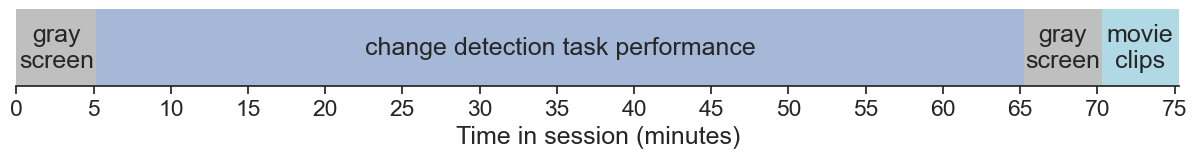

In [ ]:
ppf.add_stimulus_blocks(stim_table, xlim=None, annotate_blocks=True, ax=None)